In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
import matplotlib.pyplot as plt
import math
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import os
import joblib
import json
import hashlib

from sklearn.inspection import permutation_importance
from scipy import sparse

from sklearn.base import clone
from sklearn.feature_selection import SelectFromModel


## Input datasets

In [2]:
import pandas as pd

diabetes_data = pd.read_csv("dataset_diabetes/diabetic_data.csv")
id_mapping = pd.read_csv("dataset_diabetes/IDs_mapping.csv")

In [3]:
diabetes_data.head()


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
print(id_mapping.head())

  admission_type_id    description
0                 1      Emergency
1                 2         Urgent
2                 3       Elective
3                 4        Newborn
4                 5  Not Available


## Preliminary data discription:

### Basic information

In [5]:
# print unique feature names and their data types

summary_list = []

for col in diabetes_data.columns:
    summary_list.append({
        "feature_name": col,
        "dtype": diabetes_data[col].dtype,
        "n_unique": diabetes_data[col].nunique(),
        "unique_sample": diabetes_data[col].unique()[:10]  # 只展示前10个
    })

summary_df = pd.DataFrame(summary_list)

print(summary_df)



                feature_name  dtype  n_unique  \
0               encounter_id  int64    101766   
1                patient_nbr  int64     71518   
2                       race    str         6   
3                     gender    str         3   
4                        age    str        10   
5                     weight    str        10   
6          admission_type_id  int64         8   
7   discharge_disposition_id  int64        26   
8        admission_source_id  int64        17   
9           time_in_hospital  int64        14   
10                payer_code    str        18   
11         medical_specialty    str        73   
12        num_lab_procedures  int64       118   
13            num_procedures  int64         7   
14           num_medications  int64        75   
15         number_outpatient  int64        39   
16          number_emergency  int64        33   
17          number_inpatient  int64        21   
18                    diag_1    str       717   
19                  

### Sample-to-Feature Ratio

In [6]:
n_samples = diabetes_data.shape[0]
n_features = diabetes_data.shape[1] - 1   # substract the label: readmitted \

print("Number of samples:", n_samples)
print("Number of features:", n_features)
print("Sample-to-feature ratio:", n_samples / n_features)

Number of samples: 101766
Number of features: 49
Sample-to-feature ratio: 2076.8571428571427


### Data Types distribution

In [7]:
diabetes_data.dtypes.value_counts()

str      37
int64    13
Name: count, dtype: int64

### Check missing value

In [10]:
for column in diabetes_data.columns:
    if diabetes_data[column].isna().sum() > 0:
        print(f"Column '{column}' has {diabetes_data[column].isna().sum()} missing values.")

Column 'max_glu_serum' has 96420 missing values.
Column 'A1Cresult' has 84748 missing values.


In [11]:
df_temp = diabetes_data.replace("?", np.nan, )
df_temp = df_temp.replace("Unknown/Invalid", np.nan)

In [12]:
missing_ratio = df_temp.isna().mean().sort_values(ascending=False)
print(missing_ratio.head(20))

weight                      0.968585
max_glu_serum               0.947468
A1Cresult                   0.832773
medical_specialty           0.490822
payer_code                  0.395574
race                        0.022336
diag_3                      0.013983
diag_2                      0.003518
diag_1                      0.000206
gender                      0.000029
time_in_hospital            0.000000
admission_source_id         0.000000
num_lab_procedures          0.000000
encounter_id                0.000000
patient_nbr                 0.000000
discharge_disposition_id    0.000000
admission_type_id           0.000000
age                         0.000000
number_inpatient            0.000000
number_emergency            0.000000
dtype: float64


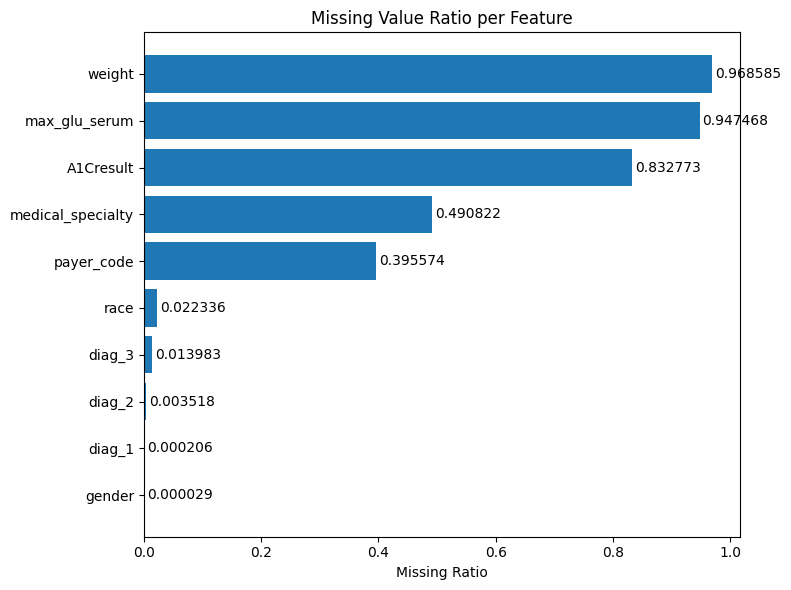

In [15]:
# 只保留非0的特征
missing_nonzero = missing_ratio[missing_ratio > 0]

# 排序方便画 horizontal bar
missing_nonzero = missing_nonzero.sort_values()

plt.figure(figsize=(8,6))

bars = plt.barh(missing_nonzero.index, missing_nonzero.values)

plt.xlabel("Missing Ratio")
plt.title("Missing Value Ratio per Feature")

# 在每个bar末尾添加数字
for i, v in enumerate(missing_nonzero.values):
    plt.text(v + 0.005, i, f"{v:.6f}", va='center')

plt.tight_layout()
plt.savefig("missing_ratio_plot.png", dpi=300)
plt.show()

### Whether there are multiple clinic visits or not

In [49]:
diabetes_data["patient_nbr"].duplicated().any()

np.True_

In [62]:
visit_counts = diabetes_data["patient_nbr"].value_counts()

print(visit_counts.head())
print("\n")

total_patients = diabetes_data["patient_nbr"].nunique()

multi_visit_patients = (visit_counts > 1).sum()
print("Number of patients with multiple visits:", multi_visit_patients)

multi_ratio = multi_visit_patients / total_patients

print("Total patients:", total_patients)
print("Patients with multiple visits:", multi_visit_patients)
print("Proportion:", multi_ratio)

patient_nbr
88785891    40
43140906    28
1660293     23
23199021    23
88227540    23
Name: count, dtype: int64


Number of patients with multiple visits: 16773
Total patients: 71518
Patients with multiple visits: 16773
Proportion: 0.23452837048015884


### Check unbalanced data

In [5]:
Binary = diabetes_data["readmitted"].map(
    lambda x: 0 if x == "NO" else 1
)

In [7]:
class_counts = Binary.value_counts()
class_ratio = Binary.value_counts(normalize=True)

print("Counts:\n", class_counts)
print("Ratio:\n", class_ratio)

Counts:
 readmitted
0    54864
1    46902
Name: count, dtype: int64
Ratio:
 readmitted
0    0.539119
1    0.460881
Name: proportion, dtype: float64


In [8]:
majority = class_counts.max()
minority = class_counts.min()
imbalance_ratio = majority / minority

print("Imbalance Ratio:", imbalance_ratio)

Imbalance Ratio: 1.169758219265703


basically balanced

## Train, validation, test split

In [144]:
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit

df = diabetes_data.copy()

X = df.drop(columns=["readmitted"])
y = df["readmitted"]
groups = df["patient_nbr"].to_numpy()


In [145]:
# 1) Use StratifiedGroupKFold to put one fold as test（approximatelly 20%）
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
(train_all_idx, test_idx) = next(sgkf.split(X, y, groups=groups))

df_train_all = df.iloc[train_all_idx].reset_index(drop=True)
df_test     = df.iloc[test_idx].reset_index(drop=True)

In [146]:
df_test

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
2,28236,89869032,AfricanAmerican,Female,[40-50),?,1,1,7,9,...,No,Steady,No,No,No,No,No,No,Yes,>30
3,40926,85504905,Caucasian,Female,[40-50),?,1,3,7,7,...,No,Down,No,No,No,No,No,Ch,Yes,<30
4,77076,92519352,AfricanAmerican,Male,[50-60),?,1,1,7,4,...,No,Steady,No,No,No,No,No,Ch,Yes,<30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20349,443816024,106392411,Caucasian,Female,[70-80),?,3,6,1,3,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
20350,443824292,138784172,Caucasian,Female,[80-90),?,3,1,1,3,...,No,Down,No,No,No,No,No,Ch,Yes,<30
20351,443842070,140199494,Other,Female,[60-70),?,1,1,7,2,...,No,Steady,No,No,No,No,No,No,Yes,>30
20352,443842136,181593374,Caucasian,Female,[70-80),?,1,1,7,5,...,No,Steady,No,No,No,No,No,No,Yes,NO


In [147]:
# 2) Use GroupShuffleSplit in trainval to cut val（also can use SGKF again for stratified group split）
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_left_idx, train_sampled_idx = next(gss.split(
    df_train_all, df_train_all["readmitted"], groups=df_train_all["patient_nbr"]
))

df_train_left = df_train_all.iloc[train_left_idx].reset_index(drop=True)
df_train   = df_train_all.iloc[train_sampled_idx].reset_index(drop=True)

In [148]:
# check patient disjoint
train_p = set(df_train["patient_nbr"])
test_p  = set(df_test["patient_nbr"])
assert train_p.isdisjoint(test_p) 

### save as new .csv file

In [157]:
df_train.to_csv("./dataset_diabetes/train.csv", index=False)
#df_val.to_csv("./dataset_diabetes/val.csv", index=False)
df_test.to_csv("./dataset_diabetes/test.csv", index=False)

In [156]:
print(len(df_train), len(df_test))

16085 20354


## EDA

In [158]:
df = pd.read_csv("./dataset_diabetes/train.csv")

### Basic info

In [159]:
# -----------------------------
# 1) overall information ：shape / dtype / memory usage / sample-to-feature ratio
# -----------------------------
print("Shape:", df.shape)
n_samples, n_features = df.shape
print(f"Sample-to-features ratio: {n_samples / n_features:.1f}")

dtype_counts = df.dtypes.value_counts()
print("\nDtype counts:\n", dtype_counts)

mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
print(f"\nApprox memory usage: {mem_mb:.2f} MB")

Shape: (16085, 50)
Sample-to-features ratio: 321.7

Dtype counts:
 str      37
int64    13
Name: count, dtype: int64

Approx memory usage: 34.81 MB


### Missing value

In [160]:
df = df.replace("?", np.nan, )
df = df.replace("Unknown/Invalid", np.nan)
missing_ratio = df.isna().mean().sort_values(ascending=False)
print(missing_ratio.head(20))

weight                      0.967547
max_glu_serum               0.947404
A1Cresult                   0.829655
medical_specialty           0.488094
payer_code                  0.398259
race                        0.024246
diag_3                      0.013802
diag_2                      0.003295
diag_1                      0.000124
gender                      0.000062
time_in_hospital            0.000000
admission_source_id         0.000000
num_lab_procedures          0.000000
encounter_id                0.000000
patient_nbr                 0.000000
discharge_disposition_id    0.000000
admission_type_id           0.000000
age                         0.000000
number_inpatient            0.000000
number_emergency            0.000000
dtype: float64


In [161]:
pd.crosstab(df["nateglinide"], df["readmitted"], normalize="index")

readmitted,<30,>30,NO
nateglinide,,,
Down,0.000000,0.333333,0.666667
No,0.108709,0.346742,0.544549
Steady,0.085470,0.341880,0.572650
Up,0.000000,0.400000,0.600000


In [162]:
pd.crosstab(df["chlorpropamide"], df["readmitted"], normalize="index")

readmitted,<30,>30,NO
chlorpropamide,,,
No,0.10856,0.346647,0.544793
Steady,0.00000,0.333333,0.666667
Up,0.00000,1.000000,0.000000


In [163]:
pd.crosstab(df["acarbose"], df["readmitted"])

readmitted,<30,>30,NO
acarbose,,,
No,1741,5555,8741
Steady,3,22,21
Up,1,0,1


In [100]:
pd.crosstab(df["glyburide-metformin"], df["readmitted"])

readmitted,<30,>30,NO
glyburide-metformin,,,
Down,0,0,2
No,7290,22679,34907
Steady,50,179,214
Up,0,1,5


same type as original dataset before partition

### Visit distribution


encounter_id unique: 16085  / rows: 16085
Duplicated encounter_id rows: 0

patient_nbr unique: 11408  / rows: 16085


count    11408.000000
mean         1.409975
std          1.012655
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         16.000000
Name: count, dtype: float64

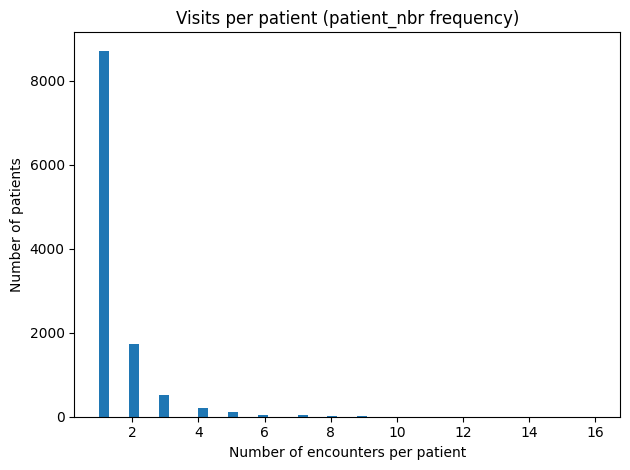

In [164]:
# -----------------------------
# Check multi-visit ：encounter_id / patient_nbr
# -----------------------------
if "encounter_id" in df.columns:
    n_unique_enc = df["encounter_id"].nunique()
    print("\nencounter_id unique:", n_unique_enc, " / rows:", len(df))
    dup_enc = df.duplicated("encounter_id").sum()
    print("Duplicated encounter_id rows:", dup_enc)

if "patient_nbr" in df.columns:
    n_unique_pat = df["patient_nbr"].nunique()
    print("\npatient_nbr unique:", n_unique_pat, " / rows:", len(df))
    # patient_nbr can be duplicated since one patient can have multiple visits, so we check the distribution of visit counts per patient
    visits_per_patient = df["patient_nbr"].value_counts()
    display(visits_per_patient.describe())

    plt.figure()
    plt.hist(visits_per_patient.values, bins=50)
    plt.title("Visits per patient (patient_nbr frequency)")
    plt.xlabel("Number of encounters per patient")
    plt.ylabel("Number of patients")
    plt.tight_layout()
    plt.show()

### histogram and type distribution figures

In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

def plot_features_in_grids(df, exclude_cols=None, top_k=15):
    if exclude_cols is None:
        exclude_cols = []

    df_plot = df.copy()
    df_plot = df_plot.replace("?", np.nan)

    feature_cols = [c for c in df_plot.columns if c not in exclude_cols]

    num_cols = df_plot[feature_cols].select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [c for c in feature_cols if c not in num_cols]

    print(f"Numeric: {len(num_cols)}, Categorical: {len(cat_cols)}")

    # combine numeric and categorical columns for plotting
    all_cols = num_cols + cat_cols

    # every 9 features in one grid
    group_size = 9
    n_groups = math.ceil(len(all_cols) / group_size)

    for g in range(n_groups):
        cols_subset = all_cols[g*group_size:(g+1)*group_size]

        fig, axes = plt.subplots(3, 3, figsize=(18, 12))
        axes = axes.flatten()

        for i, col in enumerate(cols_subset):
            ax = axes[i]

            if col in num_cols:
                data = df_plot[col].dropna()
                if len(data) > 0:
                    ax.hist(data, bins=30)
                ax.set_title(f"{col} (numeric)")
                ax.set_xlabel(col)
                ax.set_ylabel("Count")

            else:
                data = df_plot[col]
                value_counts = data.value_counts(dropna=False)

                if len(value_counts) > top_k:
                    value_counts = value_counts.head(top_k)

                # handle NaN safely
                index_str = (
                    value_counts.index
                    .to_series()
                    .replace({np.nan: "Missing"})
                    .astype(str)
                )

                ax.bar(index_str, value_counts.values)
                ax.set_title(f"{col} (categorical)")
                ax.set_ylabel("Count")
                ax.tick_params(axis="x", rotation=45)

        # clore the empty subplots
        for j in range(len(cols_subset), 9):
            axes[j].axis("off")

        plt.tight_layout()
        plt.show()

Numeric: 11, Categorical: 36


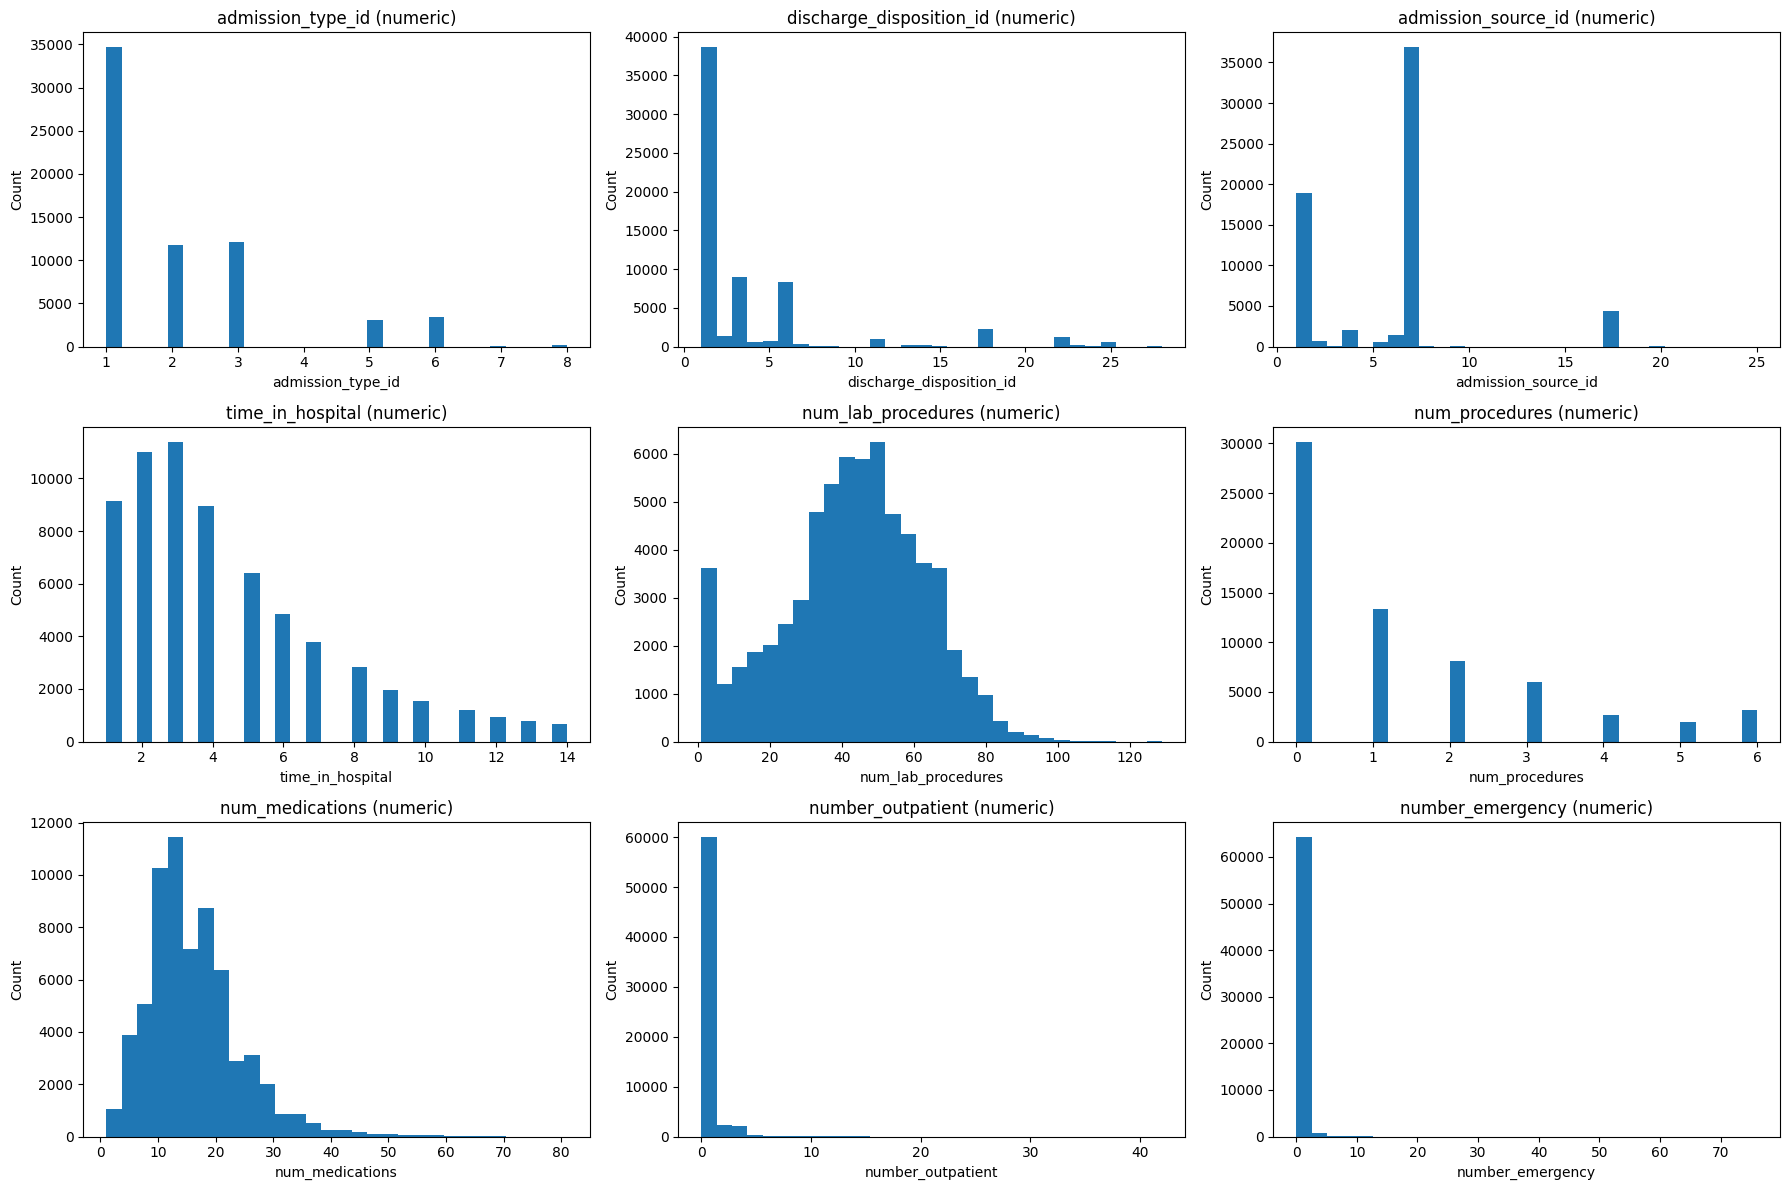

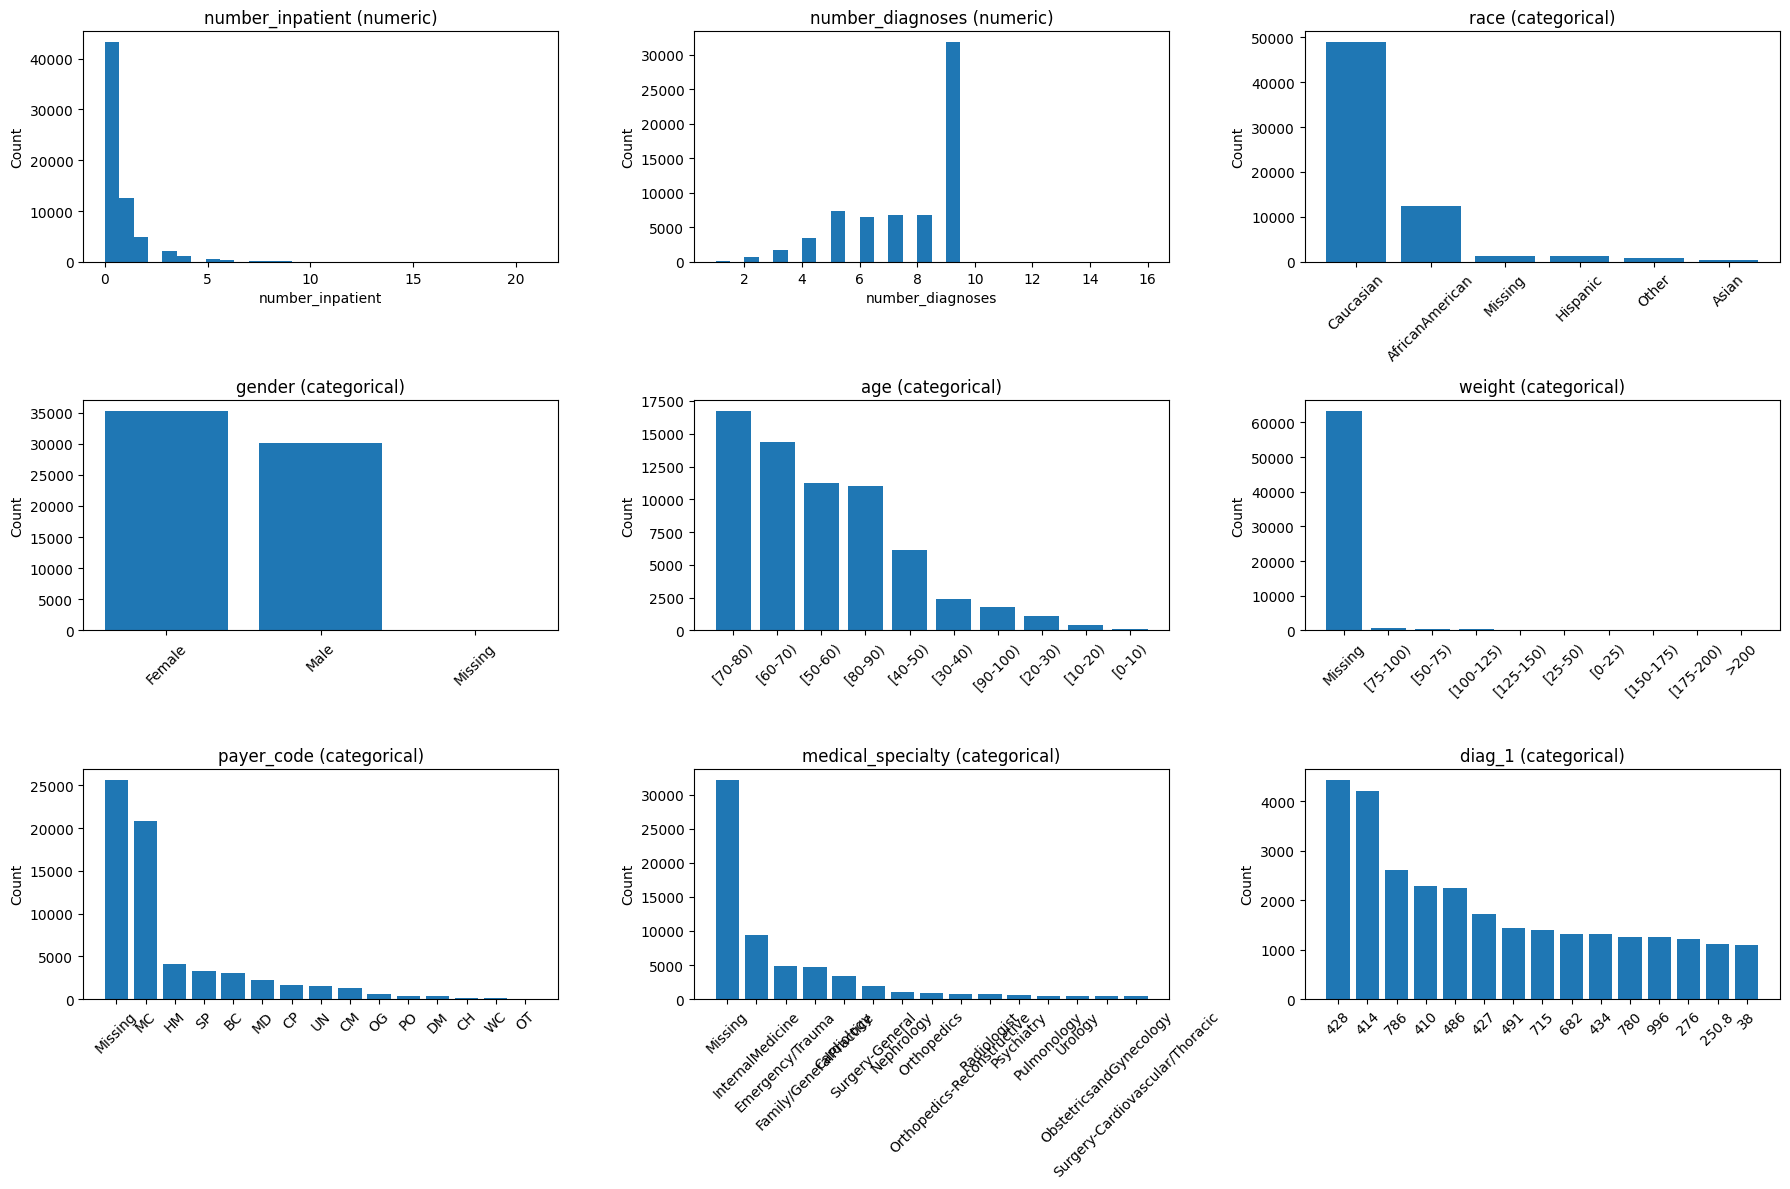

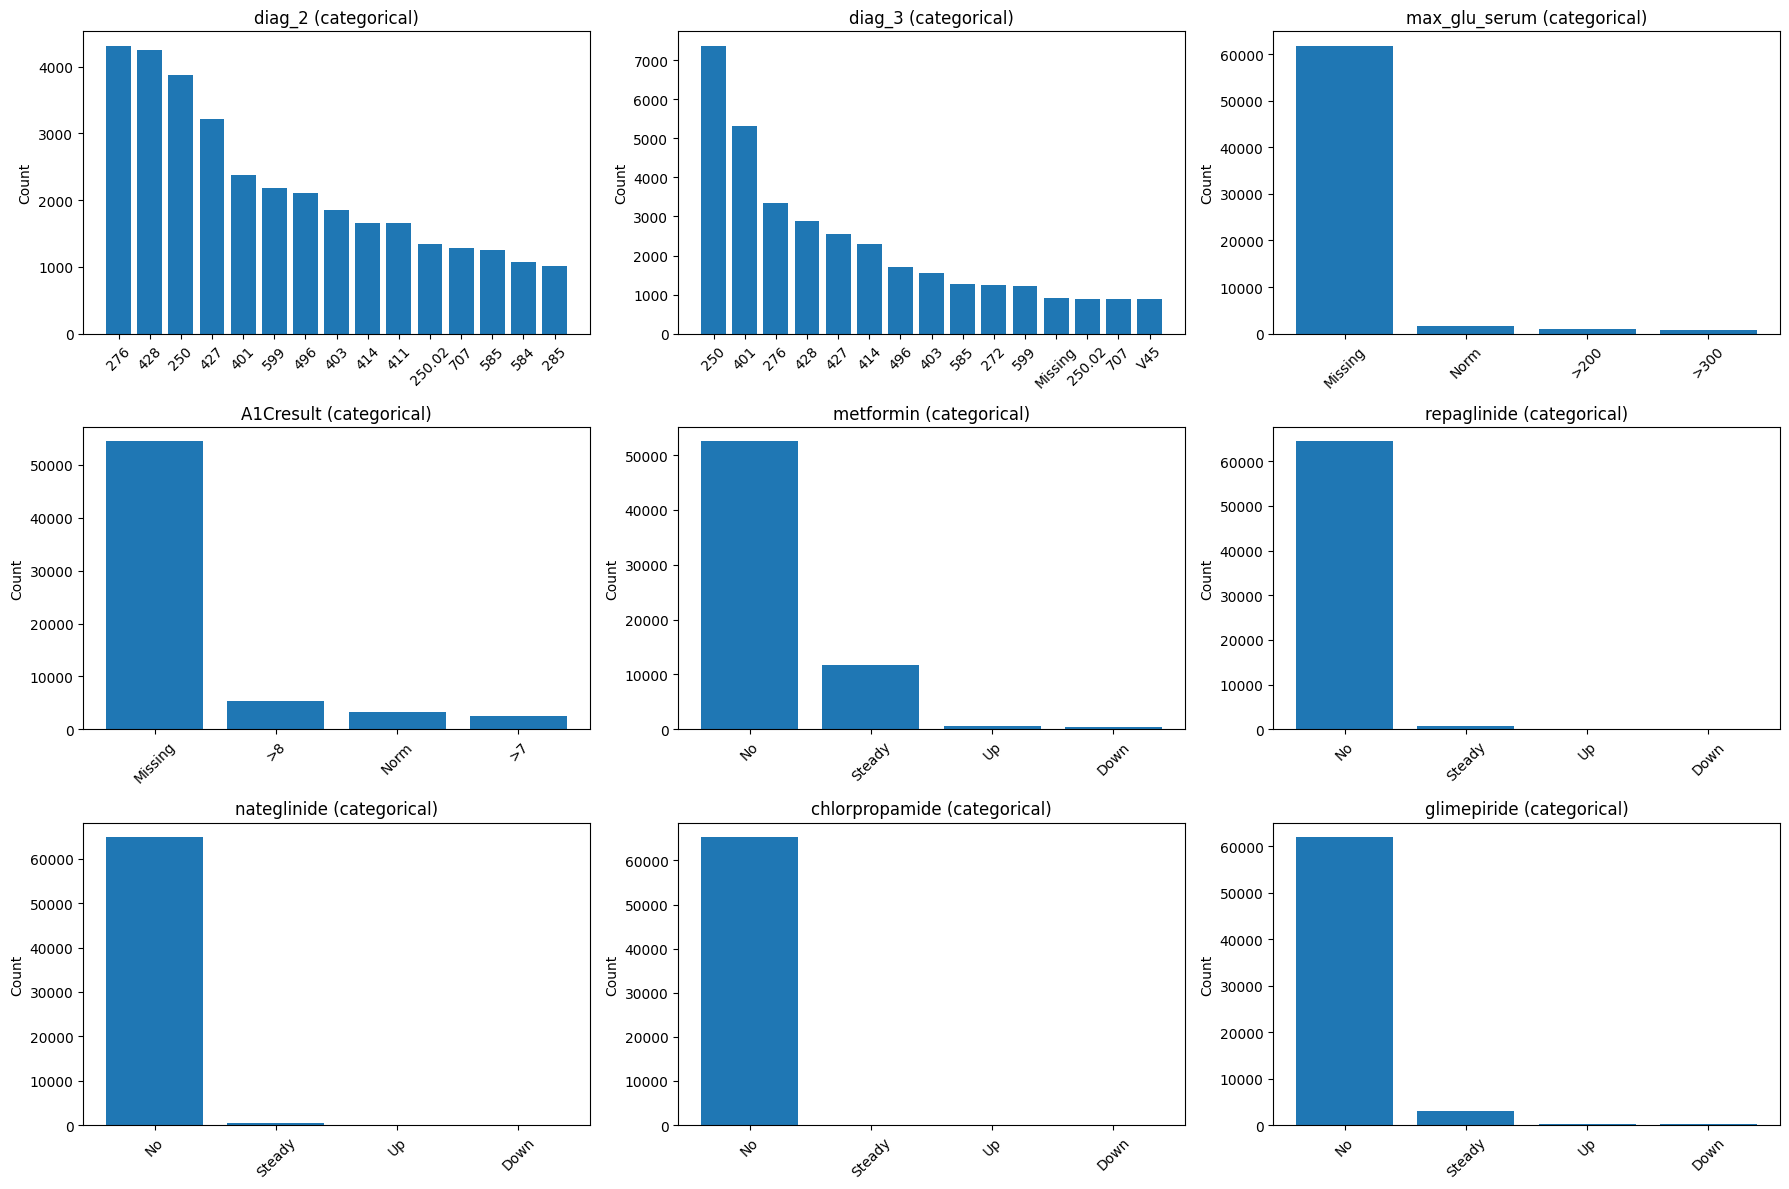

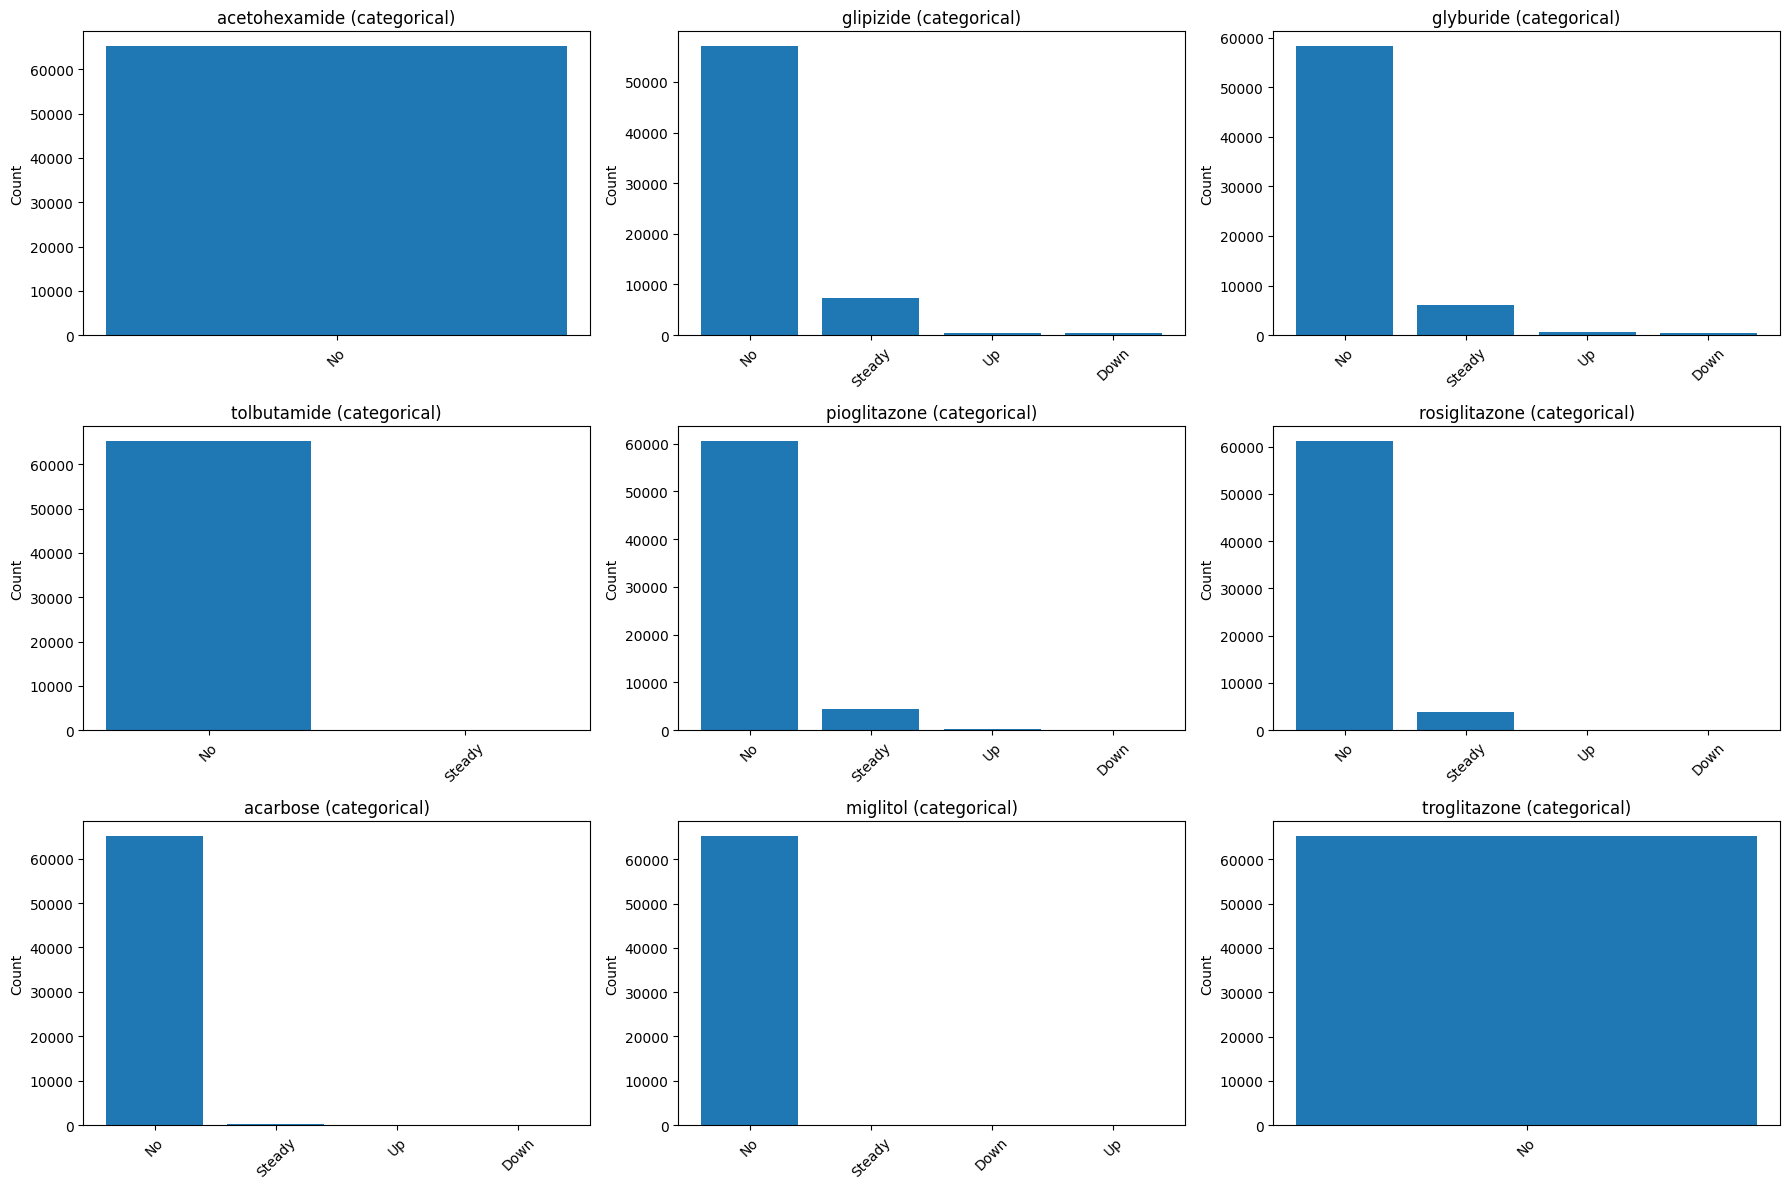

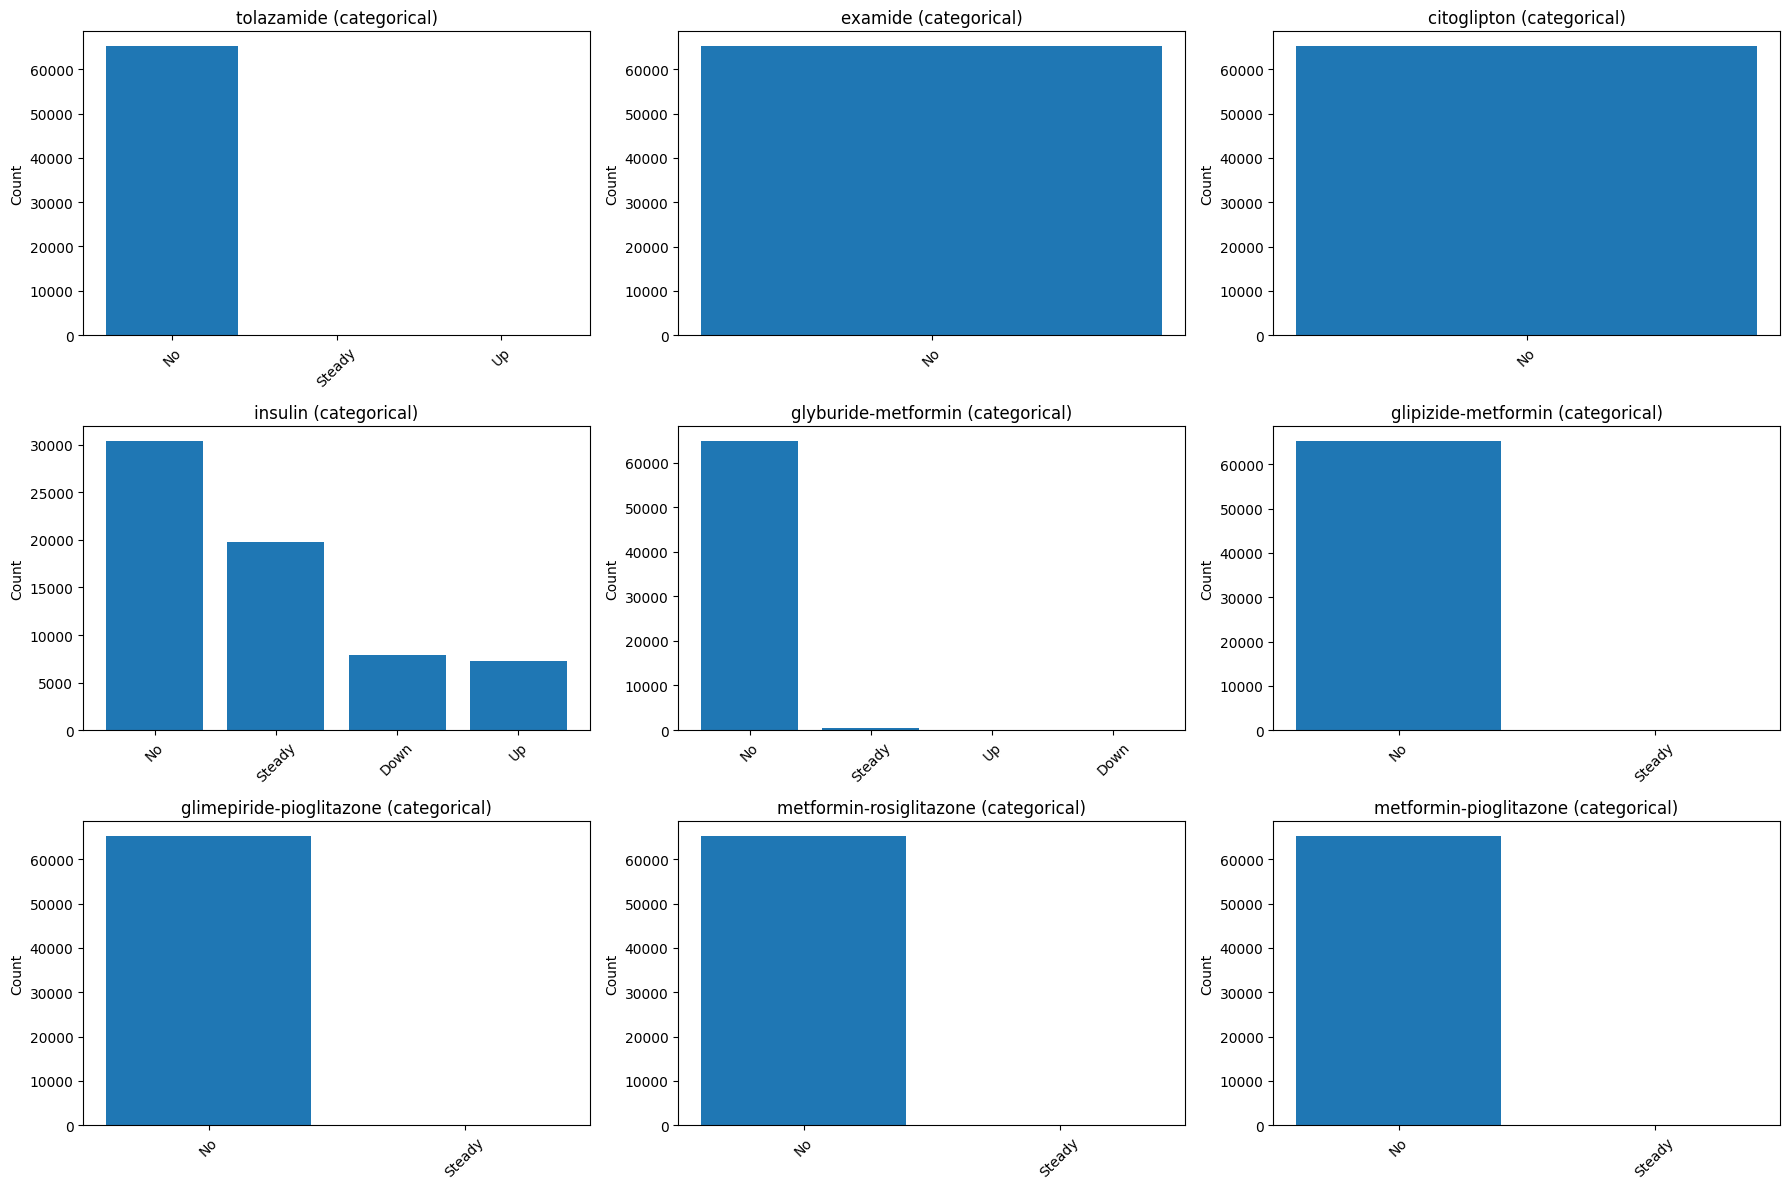

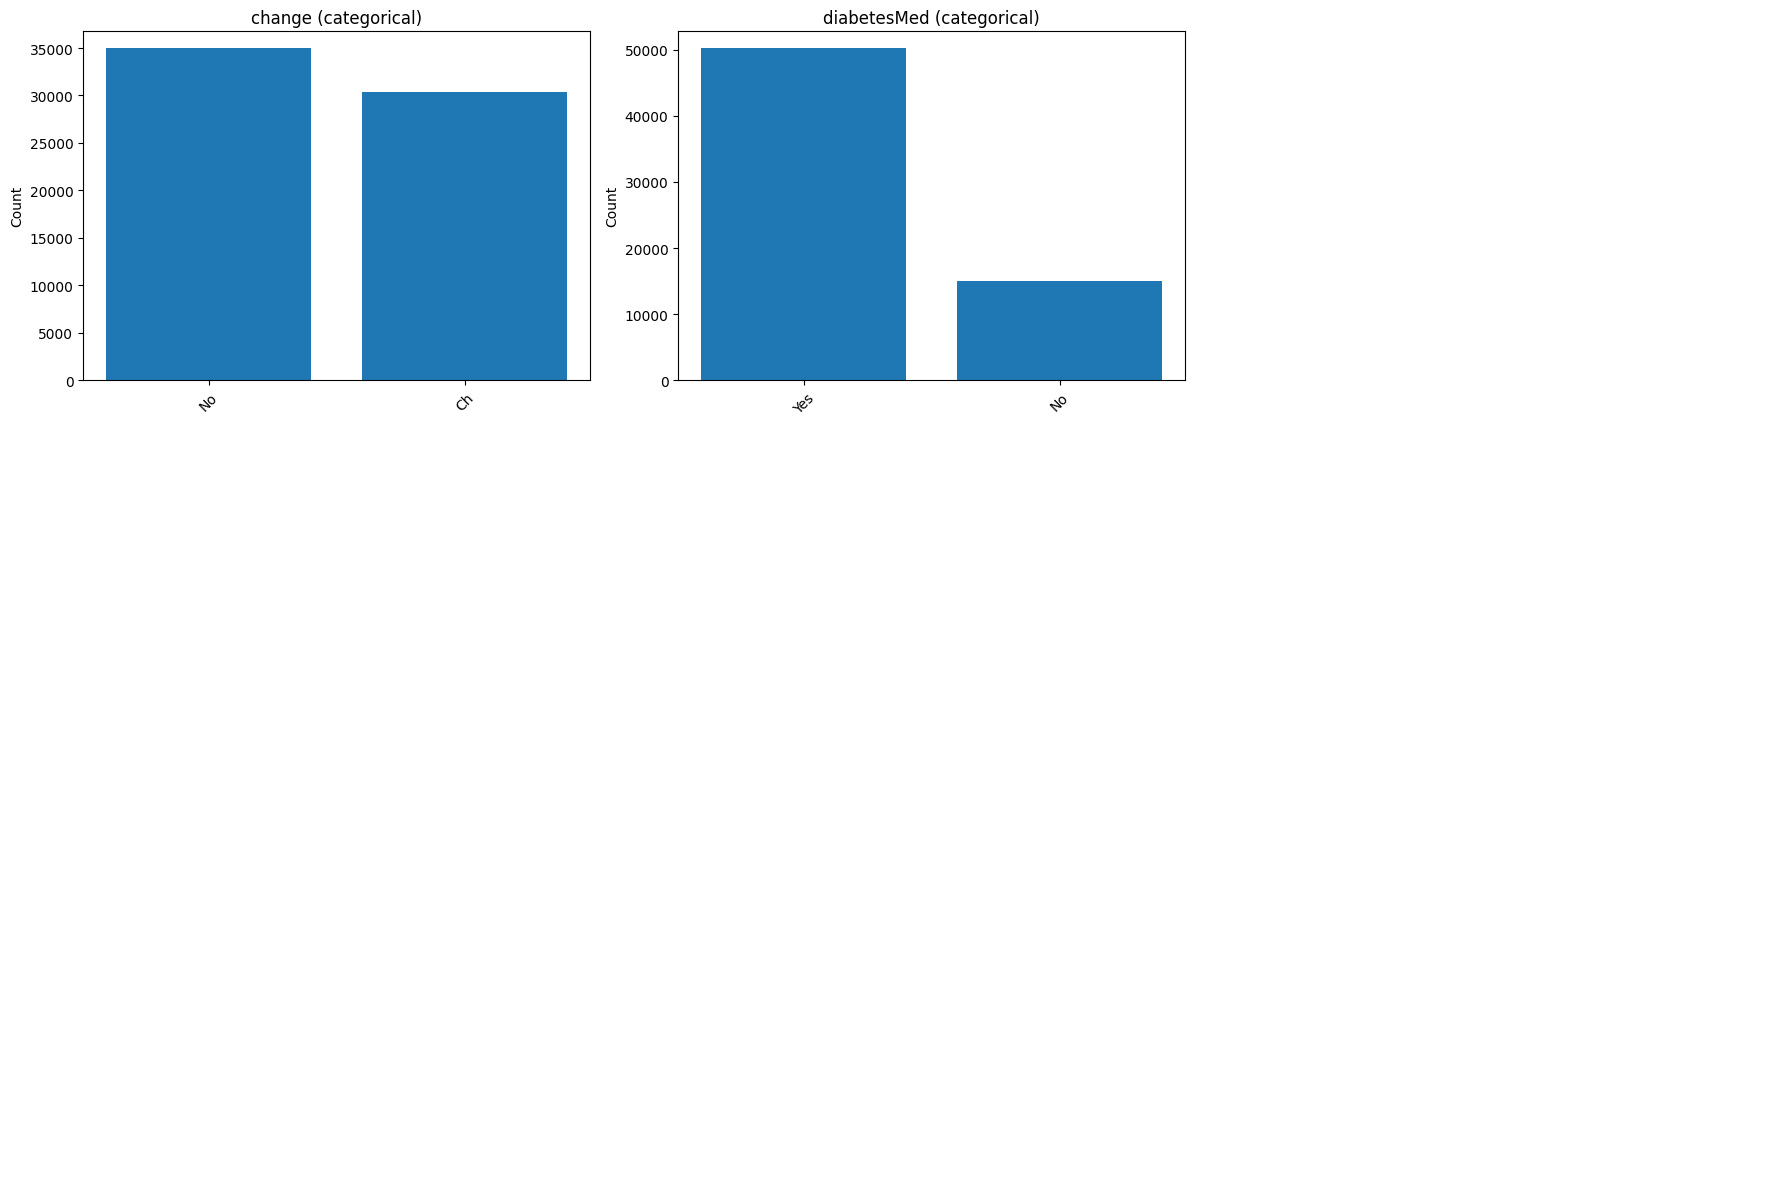

In [42]:
plot_features_in_grids(
    df,
    exclude_cols=["readmitted", "encounter_id", "patient_nbr"],
    top_k=15
)

## Preprocessing

### X,y split

In [20]:
df_train = pd.read_csv("./dataset_diabetes/train.csv")
#df_val   = pd.read_csv("./dataset_diabetes/val.csv")
df_test  = pd.read_csv("./dataset_diabetes/test.csv")

In [21]:
X_train = df_train.drop(columns=["readmitted"])
y_train = df_train["readmitted"]
y_train = y_train.map({">30": 1, "<30": 1, "NO": 0})

X_test = df_test.drop(columns=["readmitted"])
y_test = df_test["readmitted"]
y_test = y_test.map({">30": 1, "<30": 1, "NO": 0})


In [22]:
print(X_train.index.equals(X_test.index))

False


### Replace invalid value

In [23]:
import numpy as np
import pandas as pd

def replace_invalid_values(X):
    X = X.copy()
    
    # 统一替换
    invalid_values = ["?", "Unknown/Invalid", ""]
    X = X.replace(invalid_values, np.nan)
    
    return X

replace_invalid_values_transformer = FunctionTransformer(replace_invalid_values, feature_names_out="one-to-one")

In [24]:
replace_invalid_values(X_train).isna().sum().sort_values(ascending=False).head(20)

weight                      15563
max_glu_serum               15239
A1Cresult                   13345
medical_specialty            7851
payer_code                   6406
race                          390
diag_3                        222
diag_2                         53
diag_1                          2
gender                          1
admission_source_id             0
time_in_hospital                0
discharge_disposition_id        0
encounter_id                    0
admission_type_id               0
age                             0
patient_nbr                     0
number_emergency                0
number_outpatient               0
num_medications                 0
dtype: int64

### Get rid of certain features

In [25]:
import pandas as pd
import numpy as np

def compute_columns_to_drop(
    X_train: pd.DataFrame,
    missing_threshold: float = 0.5,
    near_constant_threshold: float = 0.99,
    high_cardinality_threshold: int = None,
):
    """
    根据训练集统计信息，计算需要删除的列名，并返回删除原因。

    Parameters
    ----------
    X_train : pd.DataFrame
        训练集特征矩阵（只使用训练数据，避免数据泄漏）
    missing_threshold : float
        缺失比例超过该阈值则删除
    near_constant_threshold : float
        若某个值占比超过该比例则删除（近似常数）
    high_cardinality_threshold : int or None
        若类别数超过该阈值则删除（None表示不启用）

    Returns
    -------
    cols_to_drop : list
        需要删除的列名列表

    drop_details : list of str
        每个被删除列及其删除原因说明
    """

    cols_to_drop = []
    drop_details = []

    for col in X_train.columns:
        series = X_train[col]

        # 1. 缺失比例过高
        missing_ratio = series.isna().mean()
        if missing_ratio > missing_threshold:
            cols_to_drop.append(col)
            drop_details.append(
                f"列名: {col} 原因: missing_threshold 实际缺失率: {missing_ratio:.4f}"
            )
            continue

        # 2. 常数列
        nunique = series.nunique(dropna=False)
        if nunique <= 1:
            cols_to_drop.append(col)
            drop_details.append(
                f"列名: {col} 原因: constant_column 唯一值数量: {nunique}"
            )
            continue

        # 3. 近似常数列
        value_counts = series.value_counts(normalize=True, dropna=False)
        max_ratio = value_counts.iloc[0]
        if max_ratio > near_constant_threshold:
            cols_to_drop.append(col)
            drop_details.append(
                f"列名: {col} 原因: near_constant_threshold 主值占比: {max_ratio:.4f}"
            )
            continue

        # 4. 高基数类别（可选）
        if high_cardinality_threshold is not None:
            if series.dtype == "object" or series.dtype.name == "category":
                cardinality = series.nunique()
                if cardinality > high_cardinality_threshold:
                    cols_to_drop.append(col)
                    drop_details.append(
                        f"列名: {col} 原因: high_cardinality_threshold 类别数量: {cardinality}"
                    )
                    continue

    return sorted(list(set(cols_to_drop))), drop_details

In [26]:
# compute_columns_to_drop(replace_invalid_values(X_train))

But some columns may have important meanings even if they are ill-distributed

In [27]:
cols_to_drop = [
    # 1. ID类变量（防止泄漏 & 无预测意义）
    "encounter_id",
    "patient_nbr",

    # 2. 完全常数列（n_unique = 1）
    "acetohexamide",
    "troglitazone",
    "examide",
    "citoglipton",

    # 3. 几乎100%单一取值的组合药物
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone",

    # 4. 极端缺失（>95%）且缺失无明确临床含义
    "weight",
    "chlorpropamide",
    "acarbose",
    "glyburide-metformin",
    "nateglinide",  # 虽然有明确临床含义，但从交叉表分析看，nateglinide与readmitted几乎没有关系，且缺失值也没有明确临床含义，因此也考虑删除

    # 5. 极端近常数且医学意义弱
    "tolbutamide",
    "miglitol",
    "tolazamide"
]



def drop_columns(X):
    X = X.copy()

    cols_to_drop = [
    # 1. ID类变量（防止泄漏 & 无预测意义）
    "encounter_id",
    "patient_nbr",

    # 2. 完全常数列（n_unique = 1）
    "acetohexamide",
    "troglitazone",
    "examide",
    "citoglipton",

    # 3. 几乎100%单一取值的组合药物
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone",

    # 4. 极端缺失（>95%）且缺失无明确临床含义
    "weight",
    "nateglinide",  # 虽然有明确临床含义，但从交叉表分析看，nateglinide与readmitted几乎没有关系，且缺失值也没有明确临床含义，因此也考虑删除
    "chlorpropamide",
    "acarbose",
    "glyburide-metformin",

    # 5. 极端近常数且医学意义弱
    "tolbutamide",
    "miglitol",
    "tolazamide"
    ]

    X = X.drop(columns=cols_to_drop, errors="ignore")
    return X


drop_transformer = FunctionTransformer(drop_columns)

### Feature-wise preprocessing

#### prelimenary analysis

In [28]:
# ## After dropping columns, we can check the remaining columns
# columns_to_keep = [c for c in X_train.columns.to_list() if c not in cols_to_drop]
# print("Columns to keep:", columns_to_keep)
# print("Number of columns to keep:", len(columns_to_keep))

In [29]:
# pipe_temp = Pipeline(steps=[  
#     ("label_transform", replace_invalid_values_transformer), 
#     ("drop_columns", drop_transformer)
# ])
# pipe_temp.set_output(transform="pandas")

# X_temp = pipe_temp.fit_transform(X_train)

# plot_features_in_grids(
#     X_temp,
#     exclude_cols=[],
#     top_k=15
# )

In [30]:
# missing_ratio = X_temp.isna().mean().sort_values(ascending=False)
# print(missing_ratio.head(20))

#### One hot

        "max_glu_serum",
        "A1Cresult", though have high percent missing value， but have important medical meanings, though they are reserved.

In [31]:
categorical_cols =  [
        "gender",
        "max_glu_serum",
        "A1Cresult",
        "race",
        "medical_specialty",
        "payer_code",
        "glyburide",
        "pioglitazone",
        "rosiglitazone",
        "insulin",
        "change",
        "diabetesMed",
        "glipizide",
        "glimepiride",
        "metformin",
        "repaglinide",
        
        "admission_type_id",
        "discharge_disposition_id",
        "admission_source_id",
    ]

In [32]:
from sklearn.preprocessing import FunctionTransformer

def preprocess_for_one_hot(X, top_k=10):
    X = X.copy()

    # 1) 批量填补缺失（非 inplace）
    X = X.fillna({
        "gender": "Unknown",
        "race": "Unknown",
        "max_glu_serum": "Unknown",
        "A1Cresult": "Unknown",
        "medical_specialty": "Missing",
        "payer_code": "Missing",
    })

    # 2) top-k + Other（训练集上拟合更规范；这里只先修正你当前代码）
    for col in ["medical_specialty", "payer_code"]:
        top_categories = X[col].value_counts().nlargest(top_k).index
        X[col] = X[col].where(X[col].isin(top_categories), "Other")

    # 3) 把 id 列转成 category（注意：OneHotEncoder 也能吃 int，这步不是必须）
    cols = ["admission_type_id", "discharge_disposition_id", "admission_source_id"]
    X[cols] = X[cols].astype("category")

    return X  # 关键：必须返回 DataFrame

preprocess_for_one_hot_transformer = FunctionTransformer(preprocess_for_one_hot)

#### diag_1/diag_2.diag_3

In [33]:
import numpy as np
import pandas as pd

def icd9_to_category(code: object) -> str:
    """
    Map ICD-9 code to a coarse disease category.
    Handles missing/unknown values robustly.
    """
    if code is None or (isinstance(code, float) and np.isnan(code)):
        return "Missing"

    s = str(code).strip()
    if s == "" or s in {"?", "Unknown", "None", "nan"}:
        return "Missing"

    s_upper = s.upper()

    # ICD-9 external causes & supplementary classification
    if s_upper.startswith("E"):
        return "Injury"          # external causes
    if s_upper.startswith("V"):
        return "Supplementary"   # supplementary factors

    # Try parse numeric ICD-9
    try:
        val = float(s_upper)
    except ValueError:
        return "Other"  # unparseable tokens

    # ---- Common coarse ICD-9 groupings (chapter-like) ----
    if 1 <= val <= 139:
        return "Infectious/Parasitic"
    elif 140 <= val <= 239:
        return "Neoplasms"
    elif 240 <= val <= 279:
        # diabetes special-case
        if 250 <= val < 251:
            return "Diabetes"
        return "Endocrine/Metabolic"
    elif 280 <= val <= 289:
        return "Blood"
    elif 290 <= val <= 319:
        return "Mental"
    elif 320 <= val <= 389:
        return "Nervous/Sense"
    elif 390 <= val <= 459:
        return "Circulatory"
    elif 460 <= val <= 519:
        return "Respiratory"
    elif 520 <= val <= 579:
        return "Digestive"
    elif 580 <= val <= 629:
        return "Genitourinary"
    elif 630 <= val <= 679:
        return "Pregnancy"
    elif 680 <= val <= 709:
        return "Skin"
    elif 710 <= val <= 739:
        return "Musculoskeletal"
    elif 740 <= val <= 759:
        return "Congenital"
    elif 760 <= val <= 779:
        return "Perinatal"
    elif 780 <= val <= 799:
        return "Symptoms"
    elif 800 <= val <= 999:
        return "Injury"
    else:
        return "Other"

In [34]:

def add_diag_categories(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    for c in ["diag_1", "diag_2", "diag_3"]:
        X[c] = X[c].apply(icd9_to_category)
    return X

def select_diag_cols(X):
    # 确保返回 DataFrame，并按固定顺序取列
    return X.loc[:, ["diag_1", "diag_2", "diag_3"]]


diag_category_pipe = Pipeline([
    ("add_diag_cat", FunctionTransformer(add_diag_categories, feature_names_out="one-to-one")),
    ("select_cat_cols", FunctionTransformer(select_diag_cols, feature_names_out="one-to-one")),
    ("onehot", OneHotEncoder(handle_unknown="ignore",sparse_output=False),)
])

In [35]:

one_hot_preprocess = ColumnTransformer(
    transformers=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        ),
        (
            "diag_cat_onehot",
            diag_category_pipe,
            ["diag_1", "diag_2", "diag_3"]
        )
    ],
    remainder="passthrough"
)

from sklearn import set_config
set_config(transform_output="pandas")


#### Other features

In [36]:
def log1p_df(X: pd.DataFrame) -> pd.DataFrame:
    # assumes X is a DataFrame of numeric cols
    X=X.copy()
    X["time_in_hospital"] = np.log1p(X["time_in_hospital"])
    return X

log1p_transformer = FunctionTransformer(log1p_df, feature_names_out="one-to-one")

def age_preprocess(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    age_mapping = {
        "[0-10)": 5,
        "[10-20)": 15,
        "[20-30)": 25,
        "[30-40)": 35,
        "[40-50)": 45,
        "[50-60)": 55,
        "[60-70)": 65,
        "[70-80)": 75,
        "[80-90)": 85,
        "[90-100)": 95,
    }
    X["age"] = X["age"].map(age_mapping)
    return X

age_transformer = FunctionTransformer(age_preprocess, feature_names_out="one-to-one")

### Final pipeline

In [37]:
preprocess_pipe = Pipeline(steps=[  
    ("label_transform", replace_invalid_values_transformer), 
    ("drop_columns", drop_transformer),
    ("log1p_time_in_hospital", log1p_transformer),
    ("age_preprocess", age_transformer),
    ("pre_onehot",preprocess_for_one_hot_transformer),
    ("onehot", one_hot_preprocess),
])

preprocess_pipe.set_output(transform="pandas")


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('label_transform', ...), ('drop_columns', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function rep...001D7844D13A0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",'one-to-one'
,"kw_args kw_args: dict, default=NoneDictionary of additional key

In [38]:
# X_train_after = preprocess_pipe.fit_transform(X_train)
# X_train_after.info()

In [39]:
# missing_ratio = X_train_after.isnull().sum().sort_values(ascending=False)
# print(missing_ratio.head(20))

In [40]:
# for i, col in enumerate(X_train_after.columns.to_list()):
#     print(i, col)
#     print(X_train_after.iloc[1, i])
#     print("\n")

## Machine learning algorithem pipeline

#### Tool fuctions


In [69]:
scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "ap": "average_precision",
    "precision": "precision",
    "recall": "recall"
}
REFIT_METRIC = "roc_auc"



def plot_hyperparam_curves_from_cv_results(gs, model_name, refit_metric="roc_auc"):
    """
    gs: 已fit的 GridSearchCV
    对每个超参数（param_*）画：该参数取值 vs mean_test_{refit_metric}（对其它参数取max）
    """
    results = pd.DataFrame(gs.cv_results_)
    score_col = f"mean_test_{refit_metric}"
    std_col   = f"std_test_{refit_metric}"

    # 找到所有 param_* 列
    param_cols = [c for c in results.columns if c.startswith("param_")]
    if not param_cols:
        print(f"[{model_name}] No param grid found.")
        return

    for pcol in param_cols:
        # 把这一维拿出来：对同一参数取值，选score最大的一组（对其他参数“最优”）
        tmp = (results[[pcol, score_col, std_col]]
               .groupby(pcol, dropna=False)
               .agg({score_col: "max", std_col: "min"})  # std 用 min 作为一个保守近似（也可不画std）
               .reset_index())

        x = tmp[pcol].tolist()
        y = tmp[score_col].astype(float).values

        # 如果是数值型超参，按数值排序并用折线；否则用柱状
        is_numeric = pd.to_numeric(tmp[pcol], errors="coerce").notna().all()

        plt.figure()
        if is_numeric:
            tmp_sorted = tmp.copy()
            tmp_sorted[pcol] = pd.to_numeric(tmp_sorted[pcol])
            tmp_sorted = tmp_sorted.sort_values(pcol)

            plt.plot(tmp_sorted[pcol].values, tmp_sorted[score_col].values, marker="o")
            plt.xlabel(pcol.replace("param_", ""))
        else:
            plt.bar([str(v) for v in x], y)
            plt.xlabel(pcol.replace("param_", ""))
            plt.xticks(rotation=30, ha="right")

        plt.ylabel(f"CV mean {refit_metric} (max over other params)")
        plt.title(f"{model_name}: {refit_metric} vs {pcol.replace('param_','')}")
        plt.tight_layout()
        plt.show()

In [70]:
def plot_hyperparam_curves_from_cv_results(gs, model_name, refit_metric="roc_auc"):
    """
    gs: 已fit的 GridSearchCV
    对每个超参数画：该参数取值 vs mean_test_{refit_metric}
    （对其它参数取max）
    全部使用折线图
    """
    results = pd.DataFrame(gs.cv_results_)
    score_col = f"mean_test_{refit_metric}"
    std_col   = f"std_test_{refit_metric}"

    param_cols = [c for c in results.columns if c.startswith("param_")]
    if not param_cols:
        print(f"[{model_name}] No param grid found.")
        return

    for pcol in param_cols:

        tmp = (
            results[[pcol, score_col, std_col]]
            .groupby(pcol, dropna=False)
            .agg({score_col: "max", std_col: "min"})
            .reset_index()
        )

        param_name = pcol.replace("param_", "")

        # 判断是否数值型
        numeric_vals = pd.to_numeric(tmp[pcol], errors="coerce")

        plt.figure()

        if numeric_vals.notna().all():
            # 数值参数：按数值排序
            tmp[pcol] = numeric_vals
            tmp = tmp.sort_values(pcol)

            x = tmp[pcol].values
            labels = x
        else:
            # 非数值参数：使用序号作为x轴
            labels = tmp[pcol].astype(str).tolist()
            x = range(len(labels))

        y = tmp[score_col].astype(float).values

        plt.plot(x, y, marker="o")

        plt.xticks(x, labels, rotation=30, ha="right")
        plt.xlabel(param_name)
        plt.ylabel(f"CV mean {refit_metric} (max over other params)")
        plt.title(f"{model_name}: {refit_metric} vs {param_name}")

        plt.tight_layout()
        plt.show()

In [71]:


def tune_report_plot_save_best_per_model(
    X_train, y_train, groups_train,
    X_test, y_test,
    preprocess_pipe,
    models_and_grids,
    scoring,
    refit_metric="roc_auc",
    inner_splits=5,
    n_repeats=5,
    base_random_state=42,
    output_dir="saved_models"
):
    os.makedirs(output_dir, exist_ok=True)

    summary_rows = []
    gs_for_plots = {}
    saved_paths = {}

    for model_name, (clf, param_grid) in tqdm(
        models_and_grids.items(),
        desc="Models",
        total=len(models_and_grids)
    ):
        # 记录每个 repeat 的 best CV score -> 用于 CV mean ± std
        cv_scores_main = []

        # 记录每个 repeat 在 test 上的分数 -> 用于 test mean ± std
        test_scores_main = []

        # 用于保存“跨 repeats 中 CV 最好”的那一次，供画图 / 最终保存模型
        best_cv_score_over_repeats = -np.inf
        best_params_over_repeats = None
        best_gs_for_plot = None

        for r in tqdm(range(n_repeats), desc=f"{model_name} repeats", leave=False):
            rs = base_random_state + r
            inner_cv = StratifiedGroupKFold(
                n_splits=inner_splits,
                shuffle=True,
                random_state=rs
            )

            pipe = Pipeline([
                ("preprocess", preprocess_pipe),
                ("clf", clf)
            ])

            gs = GridSearchCV(
                estimator=pipe,
                param_grid=param_grid,
                scoring=scoring,
                refit=refit_metric,
                cv=inner_cv.split(X_train, y_train, groups=groups_train),
                n_jobs=-1,
                verbose=0,
                return_train_score=False
            )

            gs.fit(X_train, y_train)

            # ---- 记录当前 repeat 的 best CV score ----
            cv_scores_main.append(float(gs.best_score_))

            # ---- 保存跨 repeats 中 CV 最优的那一次 ----
            if gs.best_score_ > best_cv_score_over_repeats:
                best_cv_score_over_repeats = float(gs.best_score_)
                best_params_over_repeats = gs.best_params_
                best_gs_for_plot = gs

            # ---- 用当前 repeat 的 best_estimator_ 在 test 上评估 ----
            best_model_repeat = gs.best_estimator_
            y_pred = best_model_repeat.predict(X_test)

            # 注意：Pipeline 本身也有 decision_function / predict_proba（若最后一步 clf 支持）
            if hasattr(best_model_repeat, "decision_function"):
                y_score = best_model_repeat.decision_function(X_test)
            elif hasattr(best_model_repeat, "predict_proba"):
                y_score = best_model_repeat.predict_proba(X_test)[:, 1]
            else:
                y_score = None

            if refit_metric == "roc_auc":
                test_main = roc_auc_score(y_test, y_score) if y_score is not None else np.nan
            elif refit_metric == "ap":
                test_main = average_precision_score(y_test, y_score) if y_score is not None else np.nan
            elif refit_metric == "accuracy":
                test_main = accuracy_score(y_test, y_pred)
            elif refit_metric == "f1":
                test_main = f1_score(y_test, y_pred)
            elif refit_metric == "precision":
                test_main = precision_score(y_test, y_pred, zero_division=0)
            elif refit_metric == "recall":
                test_main = recall_score(y_test, y_pred, zero_division=0)
            else:
                raise ValueError(f"Unsupported refit_metric: {refit_metric}")

            test_scores_main.append(float(test_main))

        # ---------- 保存每个模型最终的最优 pipeline ----------
        # 用“跨 repeats 里 CV 最好”的 best_params 重新在全量 X_train 上 fit
        if best_params_over_repeats is None:
            raise RuntimeError(f"[{model_name}] best_params_over_repeats is None.")

        final_pipe = Pipeline([
            ("preprocess", preprocess_pipe),
            ("clf", clf)
        ])
        final_pipe.set_params(**best_params_over_repeats)
        final_pipe.fit(X_train, y_train)

        save_path = os.path.join(output_dir, f"best_{model_name}.joblib")
        joblib.dump(final_pipe, save_path)
        saved_paths[model_name] = save_path

        # 用于后续画图
        gs_for_plots[model_name] = best_gs_for_plot

        # ---------- 3.5 表格：CV mean±std + test mean±std ----------
        row = {
            "model": model_name,
            f"cv_{refit_metric}_mean": np.nanmean(cv_scores_main),
            f"cv_{refit_metric}_std": (
                np.nanstd(cv_scores_main, ddof=1) if len(cv_scores_main) > 1 else 0.0
            ),
            f"test_{refit_metric}_mean": np.nanmean(test_scores_main),
            f"test_{refit_metric}_std": (
                np.nanstd(test_scores_main, ddof=1) if len(test_scores_main) > 1 else 0.0
            ),
            f"best_cv_{refit_metric}_over_repeats": best_cv_score_over_repeats,
            "best_params_over_repeats": str(best_params_over_repeats),
            "saved_pipeline_path": save_path
        }
        summary_rows.append(row)

    summary_df = (
        pd.DataFrame(summary_rows)
        .sort_values(f"test_{refit_metric}_mean", ascending=False)
        .reset_index(drop=True)
    )

    # ---------- 3.4 作图 ----------
    for model_name, gs in gs_for_plots.items():
        if gs is not None:
            plot_hyperparam_curves_from_cv_results(gs, model_name, refit_metric=refit_metric)

    return summary_df, saved_paths, gs_for_plots

use this function below to get a more specific output

In [72]:


def _score_from_metric(refit_metric, y_true, y_pred, y_score):
    if refit_metric == "roc_auc":
        return roc_auc_score(y_true, y_score) if y_score is not None else np.nan
    elif refit_metric == "ap":
        return average_precision_score(y_true, y_score) if y_score is not None else np.nan
    elif refit_metric == "accuracy":
        return accuracy_score(y_true, y_pred)
    elif refit_metric == "f1":
        return f1_score(y_true, y_pred)
    elif refit_metric == "precision":
        return precision_score(y_true, y_pred, zero_division=0)
    elif refit_metric == "recall":
        return recall_score(y_true, y_pred, zero_division=0)
    else:
        raise ValueError(f"Unsupported refit_metric: {refit_metric}")


def _make_split_signature(cv, X, y, groups):
    """
    为当前 repeat 的 split 生成一个简短签名。
    如果不同 repeat 的 signature 完全一样，说明 split 实际没变。
    """
    parts = []
    for fold_id, (_, val_idx) in enumerate(cv.split(X, y, groups=groups)):
        parts.append(f"fold{fold_id}:" + ",".join(map(str, val_idx[:20])))
    raw = "|".join(parts)
    return hashlib.md5(raw.encode("utf-8")).hexdigest()


def tune_report_plot_save_best_per_model_more_specific(
    X_train, y_train, groups_train,
    X_test, y_test,
    preprocess_pipe,
    models_and_grids,
    scoring,
    refit_metric="roc_auc",
    inner_splits=5,
    n_repeats=5,
    base_random_state=42,
    output_dir="saved_models",
    verbose_repeat_details=True,
    keep_repeat_details=True,
    float_decimals=12
):
    os.makedirs(output_dir, exist_ok=True)

    summary_rows = []
    gs_for_plots = {}
    saved_paths = {}
    repeat_details_by_model = {}

    for model_name, (clf, param_grid) in tqdm(
        models_and_grids.items(),
        desc="Models",
        total=len(models_and_grids)
    ):
        cv_scores_main = []
        test_scores_main = []

        best_cv_score_over_repeats = -np.inf
        best_params_over_repeats = None
        best_gs_for_plot = None

        repeat_records = []

        for r in tqdm(range(n_repeats), desc=f"{model_name} repeats", leave=False):
            rs = base_random_state + r
            inner_cv = StratifiedGroupKFold(
                n_splits=inner_splits,
                shuffle=True,
                random_state=rs
            )

            split_signature = _make_split_signature(
                inner_cv, X_train, y_train, groups_train
            )

            pipe = Pipeline([
                ("preprocess", preprocess_pipe),
                ("clf", clf)
            ])

            # 重新生成 split generator，避免前面算 signature 时已经消耗掉
            inner_cv_for_gs = StratifiedGroupKFold(
                n_splits=inner_splits,
                shuffle=True,
                random_state=rs
            )

            gs = GridSearchCV(
                estimator=pipe,
                param_grid=param_grid,
                scoring=scoring,
                refit=refit_metric,
                cv=inner_cv_for_gs.split(X_train, y_train, groups=groups_train),
                n_jobs=-1,
                verbose=0,
                return_train_score=False
            )

            gs.fit(X_train, y_train)

            cv_score = float(gs.best_score_)
            cv_scores_main.append(cv_score)

            if gs.best_score_ > best_cv_score_over_repeats:
                best_cv_score_over_repeats = cv_score
                best_params_over_repeats = gs.best_params_
                best_gs_for_plot = gs

            best_model_repeat = gs.best_estimator_
            y_pred = best_model_repeat.predict(X_test)

            if hasattr(best_model_repeat, "decision_function"):
                y_score = best_model_repeat.decision_function(X_test)
            elif hasattr(best_model_repeat, "predict_proba"):
                y_score = best_model_repeat.predict_proba(X_test)[:, 1]
            else:
                y_score = None

            test_main = float(_score_from_metric(refit_metric, y_test, y_pred, y_score))
            test_scores_main.append(test_main)

            repeat_record = {
                "repeat": r,
                "random_state": rs,
                "split_signature": split_signature,
                "best_cv_score": cv_score,
                "test_score": test_main,
                "best_params": gs.best_params_
            }
            repeat_records.append(repeat_record)

            if verbose_repeat_details:
                print(
                    f"[{model_name}] repeat={r} | "
                    f"rs={rs} | "
                    f"split_sig={split_signature[:8]} | "
                    f"cv={cv_score:.{float_decimals}f} | "
                    f"test={test_main:.{float_decimals}f} | "
                    f"best_params={gs.best_params_}"
                )

        if best_params_over_repeats is None:
            raise RuntimeError(f"[{model_name}] best_params_over_repeats is None.")

        final_pipe = Pipeline([
            ("preprocess", preprocess_pipe),
            ("clf", clf)
        ])
        final_pipe.set_params(**best_params_over_repeats)
        final_pipe.fit(X_train, y_train)

        save_path = os.path.join(output_dir, f"best_{model_name}.joblib")
        joblib.dump(final_pipe, save_path)
        saved_paths[model_name] = save_path
        gs_for_plots[model_name] = best_gs_for_plot

        cv_mean = float(np.nanmean(cv_scores_main))
        cv_std = float(np.nanstd(cv_scores_main, ddof=1)) if len(cv_scores_main) > 1 else 0.0
        test_mean = float(np.nanmean(test_scores_main))
        test_std = float(np.nanstd(test_scores_main, ddof=1)) if len(test_scores_main) > 1 else 0.0

        unique_split_signatures = len(set(rec["split_signature"] for rec in repeat_records))
        unique_best_params = len(set(json.dumps(rec["best_params"], sort_keys=True) for rec in repeat_records))
        unique_test_scores = len(set(np.round([rec["test_score"] for rec in repeat_records], 15)))

        row = {
            "model": model_name,

            f"cv_{refit_metric}_mean": cv_mean,
            f"cv_{refit_metric}_std": cv_std,
            f"test_{refit_metric}_mean": test_mean,
            f"test_{refit_metric}_std": test_std,

            f"best_cv_{refit_metric}_over_repeats": best_cv_score_over_repeats,
            "best_params_over_repeats": str(best_params_over_repeats),
            "saved_pipeline_path": save_path,

            # ---- 诊断信息 ----
            "n_unique_split_signatures": unique_split_signatures,
            "n_unique_best_params": unique_best_params,
            "n_unique_test_scores": unique_test_scores,
            "all_test_scores_identical": unique_test_scores == 1,
            "all_splits_identical": unique_split_signatures == 1,
            "all_best_params_identical": unique_best_params == 1,
        }

        if keep_repeat_details:
            row["cv_scores_raw"] = [float(x) for x in cv_scores_main]
            row["test_scores_raw"] = [float(x) for x in test_scores_main]
            row["repeat_best_params_raw"] = [rec["best_params"] for rec in repeat_records]
            row["split_signatures_raw"] = [rec["split_signature"] for rec in repeat_records]
            repeat_details_by_model[model_name] = pd.DataFrame(repeat_records)

        summary_rows.append(row)

    summary_df = (
        pd.DataFrame(summary_rows)
        .sort_values(f"test_{refit_metric}_mean", ascending=False)
        .reset_index(drop=True)
    )

    # 保持高精度显示，避免 0.0 只是显示问题
    pd.set_option("display.float_format", lambda x: f"{x:.{float_decimals}f}")

    for model_name, gs in gs_for_plots.items():
        if gs is not None:
            plot_hyperparam_curves_from_cv_results(gs, model_name, refit_metric=refit_metric)

    return summary_df, saved_paths, gs_for_plots, repeat_details_by_model

#### LinearSVM

In [61]:
models_and_grids = {
    "LinearSVM": (
        LinearSVC(dual="auto", max_iter=20000),
        {
            "clf__C": np.logspace(-3, 2, 10)
        }
    ),}

Models:   0%|          | 0/1 [00:00<?, ?it/s]

[LinearSVM] repeat=0 | rs=42 | split_sig=346e1f2d | cv=0.672741387670 | test=0.691608623557 | best_params={'clf__C': np.float64(0.046415888336127795)}


[LinearSVM] repeat=1 | rs=43 | split_sig=a0412632 | cv=0.671954650754 | test=0.691608623557 | best_params={'clf__C': np.float64(0.046415888336127795)}


[LinearSVM] repeat=2 | rs=44 | split_sig=c12e85fe | cv=0.671331915376 | test=0.691608623557 | best_params={'clf__C': np.float64(0.046415888336127795)}


Models: 100%|██████████| 1/1 [04:33<00:00, 273.46s/it]


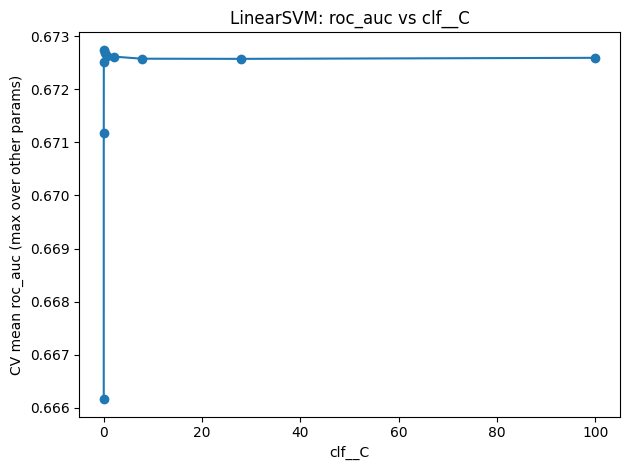

{'LinearSVM': 'saved_models\\best_LinearSVM.joblib'}

In [64]:
groups_train = X_train["patient_nbr"].copy()
groups_test = X_test["patient_nbr"].copy()

summary_df, saved_paths, gs_for_plots, repeat_details_by_model = \
    tune_report_plot_save_best_per_model_more_specific(
        X_train, y_train, groups_train,
        X_test, y_test,
        preprocess_pipe,
        models_and_grids,
        scoring,
        refit_metric="roc_auc",
        inner_splits=5,
        n_repeats=3,
        base_random_state=42,
        output_dir="saved_models",
        verbose_repeat_details=True,
        keep_repeat_details=True,
        float_decimals=12
    )

summary_df
saved_paths

In [47]:
summary_df_LinearSVM=summary_df
summary_df_LinearSVM

,model,cv_roc_auc_mean,cv_roc_auc_std,test_roc_auc_mean,test_roc_auc_std,best_cv_roc_auc_over_repeats,best_params_over_repeats,saved_pipeline_path
0,LinearSVM,0.672009,0.000706,0.691609,0.0,0.672741,{'clf__C': np.float64(0.046415888336127795)},saved_models\best_LinearSVM.joblib


In [48]:
model = joblib.load("saved_models/best_LinearSVM.joblib")

In [49]:
y_pred = model.predict(X_test)
test_accuracy = roc_auc_score(y_test, y_pred)
print("Test accuracy of loaded model:", test_accuracy)

Test accuracy of loaded model: 0.6276424851210752


In [287]:
if hasattr(model.named_steps["clf"], "decision_function"):
    y_score = model.decision_function(X_test)
elif hasattr(model.named_steps["clf"], "predict_proba"):
    y_score = model.predict_proba(X_test)[:, 1]
else:
    y_score = None

In [288]:
test_roc_auc = roc_auc_score(y_test, y_score)
print("Test ROC AUC of loaded model:", test_roc_auc)

Test ROC AUC of loaded model: 0.6916086235566551


In [331]:
test_f1 = f1_score(y_test, y_pred)
print("Test F1 score of loaded model:", test_f1)

Test F1 score of loaded model: 0.5625984729123743


In [330]:
test_recall = recall_score(y_test, y_pred)
print("Test Recall score of loaded model:", test_recall)

Test Recall score of loaded model: 0.49482997548235796


#### Random Forest

In [75]:
models_and_grids = {    "RF": (
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    {
        "clf__n_estimators": [200, 400, 600],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_leaf": [1, 2, 5]
    }
)
    }

Models: 100%|██████████| 1/1 [32:00<00:00, 1920.20s/it]


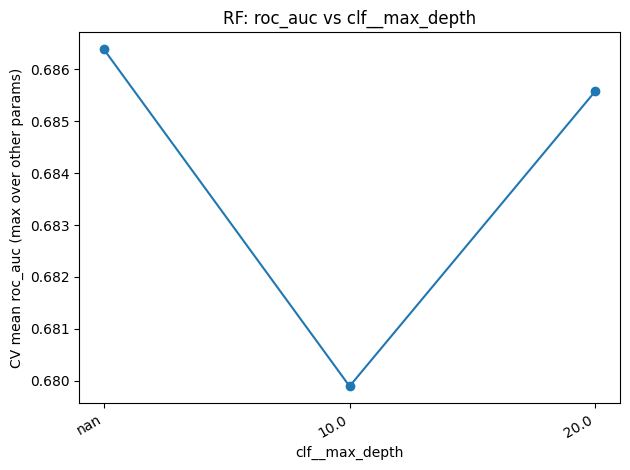

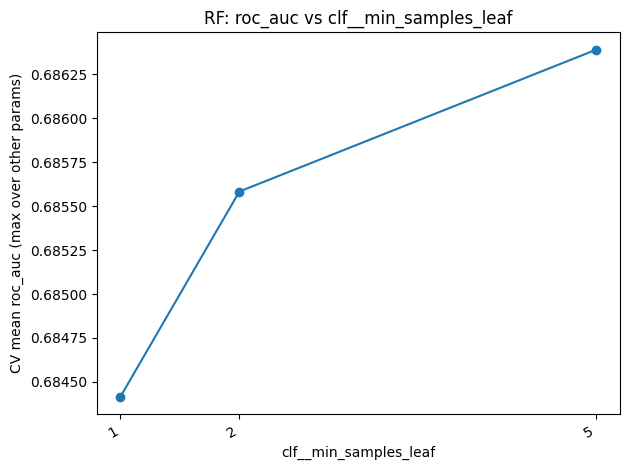

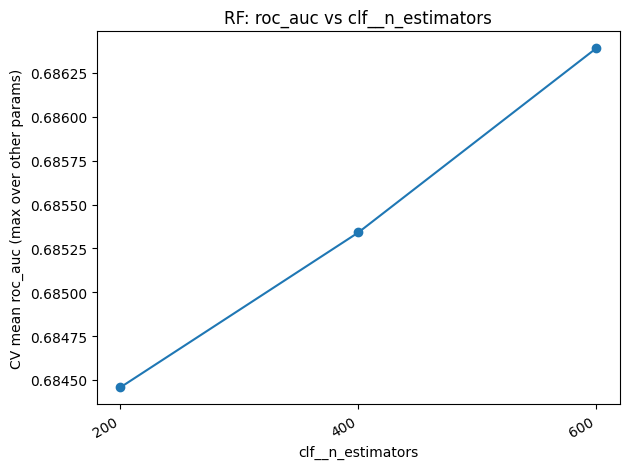

{'RF': 'saved_models\\best_RF.joblib'}

In [76]:
groups_train = X_train["patient_nbr"].copy()
groups_test = X_test["patient_nbr"].copy()

summary_df, saved_paths, gs_for_plots = tune_report_plot_save_best_per_model(
    X_train, y_train, groups_train,
    X_test, y_test,
    preprocess_pipe=preprocess_pipe,
    models_and_grids=models_and_grids,
    scoring=scoring,
    refit_metric="roc_auc",
    inner_splits=5,
    n_repeats=3,
    output_dir="saved_models"
)

summary_df
saved_paths

In [52]:
summary_df

,model,cv_roc_auc_mean,cv_roc_auc_std,test_roc_auc_mean,test_roc_auc_std,best_cv_roc_auc_over_repeats,best_params_over_repeats,saved_pipeline_path
0,RF,0.685594,0.000749,0.703776,0.000474,0.686391,"{'clf__max_depth': None, 'clf__min_samples_lea...",saved_models\best_RF.joblib


In [332]:
model = joblib.load("saved_models/best_RF.joblib")

In [335]:
y_pred = model.predict(X_test)
test_accuracy = roc_auc_score(y_test, y_pred)
print("Test accuracy of loaded model:", test_accuracy)

Test accuracy of loaded model: 0.6350863604284661


In [336]:
if hasattr(model.named_steps["clf"], "decision_function"):
    y_score = model.decision_function(X_test)
elif hasattr(model.named_steps["clf"], "predict_proba"):
    y_score = model.predict_proba(X_test)[:, 1]
else:
    y_score = None

In [337]:
test_roc_auc = roc_auc_score(y_test, y_score)
print("Test ROC AUC of loaded model:", test_roc_auc)

Test ROC AUC of loaded model: 0.7032287768040855


In [338]:
test_f1 = f1_score(y_test, y_pred)
print("Test F1 score of loaded model:", test_f1)

Test F1 score of loaded model: 0.5605033290574797


In [339]:
test_recall = recall_score(y_test, y_pred)
print("Test Recall score of loaded model:", test_recall)

Test Recall score of loaded model: 0.48907365952457094


#### HGB

In [73]:
models_and_grids = {  "HGB": (
        HistGradientBoostingClassifier(random_state=42),
        {
            "clf__learning_rate": [0.02, 0.05, 0.1, 0.2],
            "clf__max_depth": [2, 3, 5, None],
            "clf__max_leaf_nodes": [15, 31, 63]
        } )
}

Models:   0%|          | 0/1 [00:00<?, ?it/s]

Models: 100%|██████████| 1/1 [12:48<00:00, 768.75s/it]


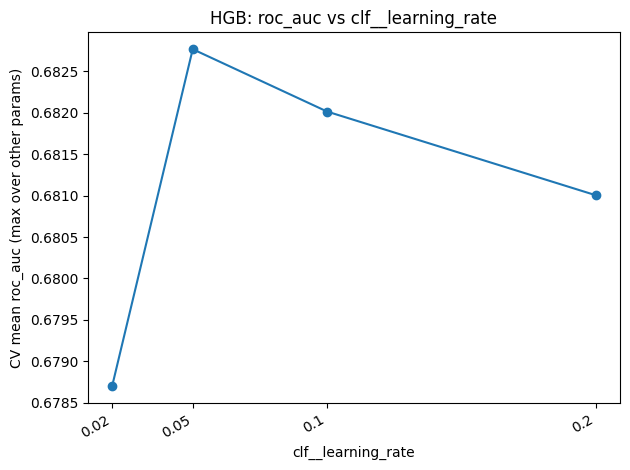

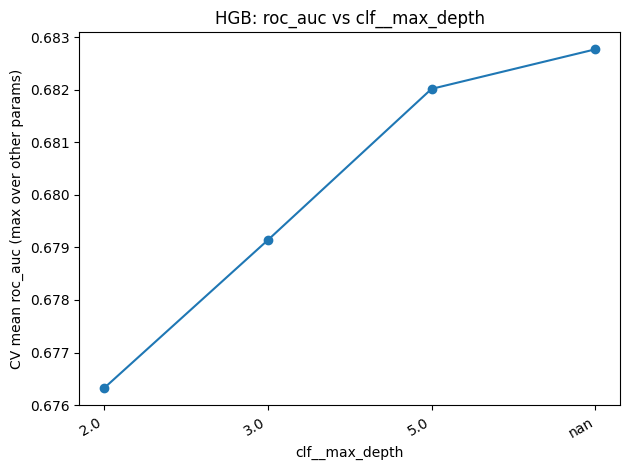

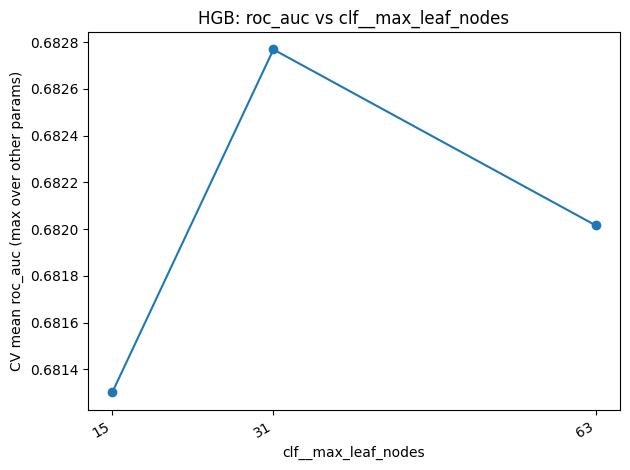

{'HGB': 'saved_models\\best_HGB.joblib'}

In [74]:
groups_train = X_train["patient_nbr"].copy()
groups_test = X_test["patient_nbr"].copy()

summary_df, saved_paths, gs_for_plots = tune_report_plot_save_best_per_model(
    X_train, y_train, groups_train,
    X_test, y_test,
    preprocess_pipe=preprocess_pipe,
    models_and_grids=models_and_grids,
    scoring=scoring,
    refit_metric="roc_auc",
    inner_splits=5,
    n_repeats=3,
    output_dir="saved_models"
)

saved_paths

In [55]:
summary_df

,model,cv_roc_auc_mean,cv_roc_auc_std,test_roc_auc_mean,test_roc_auc_std,best_cv_roc_auc_over_repeats,best_params_over_repeats,saved_pipeline_path
0,HGB,0.67965,0.002718,0.702624,0.000514,0.682769,"{'clf__learning_rate': 0.05, 'clf__max_depth':...",saved_models\best_HGB.joblib


In [77]:
model = joblib.load("saved_models/best_HGB.joblib")

In [57]:
y_pred = model.predict(X_test)
test_accuracy = roc_auc_score(y_test, y_pred)
print("Test accuracy of loaded model:", test_accuracy)

Test accuracy of loaded model: 0.6397690174057005


In [306]:
if hasattr(model.named_steps["clf"], "decision_function"):
    y_score = model.decision_function(X_test)
elif hasattr(model.named_steps["clf"], "predict_proba"):
    y_score = model.predict_proba(X_test)[:, 1]
else:
    y_score = None

test_roc_auc = roc_auc_score(y_test, y_score)
print("Test ROC AUC of loaded model:", test_roc_auc)

Test ROC AUC of loaded model: 0.7024892082069086


In [78]:
test_f1 = f1_score(y_test, y_pred)
print("Test F1 score of loaded model:", test_f1)

Test F1 score of loaded model: 0.5756764793339281


In [79]:
test_recall = recall_score(y_test, y_pred)
print("Test Recall score of loaded model:", test_recall)

Test Recall score of loaded model: 0.515936467327577


### Feature Selection

#### Linear SVM

In [62]:
# -----------------------------
# 1) 工具：取展开后的特征名
# -----------------------------
def get_expanded_feature_names(fitted_preprocess):
    """
    兼容 ColumnTransformer / Pipeline 等 get_feature_names_out 机制
    """
    if hasattr(fitted_preprocess, "get_feature_names_out"):
        return fitted_preprocess.get_feature_names_out()
    raise ValueError("preprocess step does not support get_feature_names_out().")

In [63]:
# -----------------------------
# 2) 工具：画 Top-K 水平条形图
# -----------------------------
def plot_topk_barh(names, values, title, xlabel, topk=20, normalize=False):
    names = np.asarray(names)
    values = np.asarray(values)

    if normalize:
        denom = np.max(values) if np.max(values) > 0 else 1.0
        values = values / denom

    idx = np.argsort(values)[-topk:]  # topk largest
    names_top = names[idx]
    values_top = values[idx]

    fig = plt.figure(figsize=(10, 7))
    plt.barh(range(len(idx)), values_top)
    plt.yticks(range(len(idx)), names_top)
    plt.xlabel(xlabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [64]:
# -----------------------------
# 3) 线性模型：|coef|
# -----------------------------
def linear_model_importance_from_coef(best_pipe, topk=20, normalize=True, title_prefix=""):
    preprocess = best_pipe.named_steps["preprocess"]
    clf = best_pipe.named_steps["clf"]

    feature_names = get_expanded_feature_names(preprocess)

    if not hasattr(clf, "coef_"):
        raise ValueError("This classifier has no coef_ attribute.")

    coef = clf.coef_
    # 二分类通常 shape = (1, n_features)；取一维
    if coef.ndim == 2 and coef.shape[0] == 1:
        coef = coef[0]
    elif coef.ndim == 2:
        # 万一是多分类，给一个通用做法：对各类系数取 L2 norm
        coef = np.linalg.norm(coef, axis=0)

    importance = np.abs(coef)

    plot_topk_barh(
        names=feature_names,
        values=importance,
        title=f"{title_prefix} Top-{topk} Feature Importance (|coef|)",
        xlabel="|Coefficient| (optionally normalized)",
        topk=topk,
        normalize=normalize
    )

    return feature_names, importance

In [65]:
model = joblib.load("saved_models/best_LinearSVM.joblib")

In [67]:
import pandas as pd
import numpy as np

def extract_linear_feature_importance(fitted_pipe, X_reference):
    """
    从 fitted pipeline 中提取：
    - 预处理后的特征名
    - LinearSVC / LogisticRegression 的系数
    - 绝对值重要性
    """
    preprocess = fitted_pipe.named_steps["preprocess"]
    clf = fitted_pipe.named_steps["clf"]

    # 通过 preprocess 变换一次，拿到最终列名
    X_trans = preprocess.transform(X_reference)

    if not isinstance(X_trans, pd.DataFrame):
        raise TypeError(
            "preprocess output is not a pandas DataFrame. "
            "Please check preprocess_pipe.set_output(transform='pandas')."
        )

    feature_names = X_trans.columns

    if not hasattr(clf, "coef_"):
        raise ValueError("Classifier has no coef_ attribute.")

    coefs = clf.coef_

    # 二分类情况下 shape 一般是 (1, n_features)
    if coefs.ndim == 2 and coefs.shape[0] == 1:
        coefs = coefs[0]
    else:
        # 若未来不是二分类，可改成别的聚合方式
        raise ValueError("This helper currently assumes binary classification.")

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
        "abs_coef": np.abs(coefs)
    }).sort_values("abs_coef", ascending=False).reset_index(drop=True)

    return importance_df

In [68]:
import matplotlib.pyplot as plt

def plot_top_abs_coefficients(importance_df, model_name="LinearSVC", topk=20):
    df_plot = importance_df.head(topk).sort_values("abs_coef", ascending=True)

    plt.figure(figsize=(10, 8))
    plt.barh(df_plot["feature"], df_plot["abs_coef"])
    plt.xlabel("Absolute coefficient")
    plt.ylabel("Feature")
    plt.title(f"{model_name}: Top {topk} most important features (|coef|)")
    plt.tight_layout()
    plt.show()

In [69]:
def plot_top_signed_coefficients(importance_df, model_name="LinearSVC", topk=20):
    df_plot = (
        importance_df
        .sort_values("abs_coef", ascending=False)
        .head(topk)
        .sort_values("coef", ascending=True)
    )

    plt.figure(figsize=(10, 8))
    plt.barh(df_plot["feature"], df_plot["coef"])
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title(f"{model_name}: Top {topk} features with coefficient direction")
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.tight_layout()
    plt.show()

                                              feature      coef  abs_coef
0                 onehot__discharge_disposition_id_11 -1.094626  1.094626
1                 onehot__discharge_disposition_id_14 -0.587164  0.587164
2                 onehot__discharge_disposition_id_13 -0.585423  0.585423
3                 onehot__discharge_disposition_id_15  0.388815  0.388815
4                  onehot__discharge_disposition_id_5  0.331031  0.331031
5                 onehot__discharge_disposition_id_22  0.290656  0.290656
6                   diag_cat_onehot__diag_1_Pregnancy -0.273745  0.273745
7                            onehot__glimepiride_Down -0.263048  0.263048
8                           onehot__pioglitazone_Down -0.236943  0.236943
9                      onehot__admission_source_id_20  0.236498  0.236498
10                        onehot__admission_type_id_6  0.235150  0.235150
11                      onehot__admission_source_id_4 -0.216453  0.216453
12                onehot__discharge_di

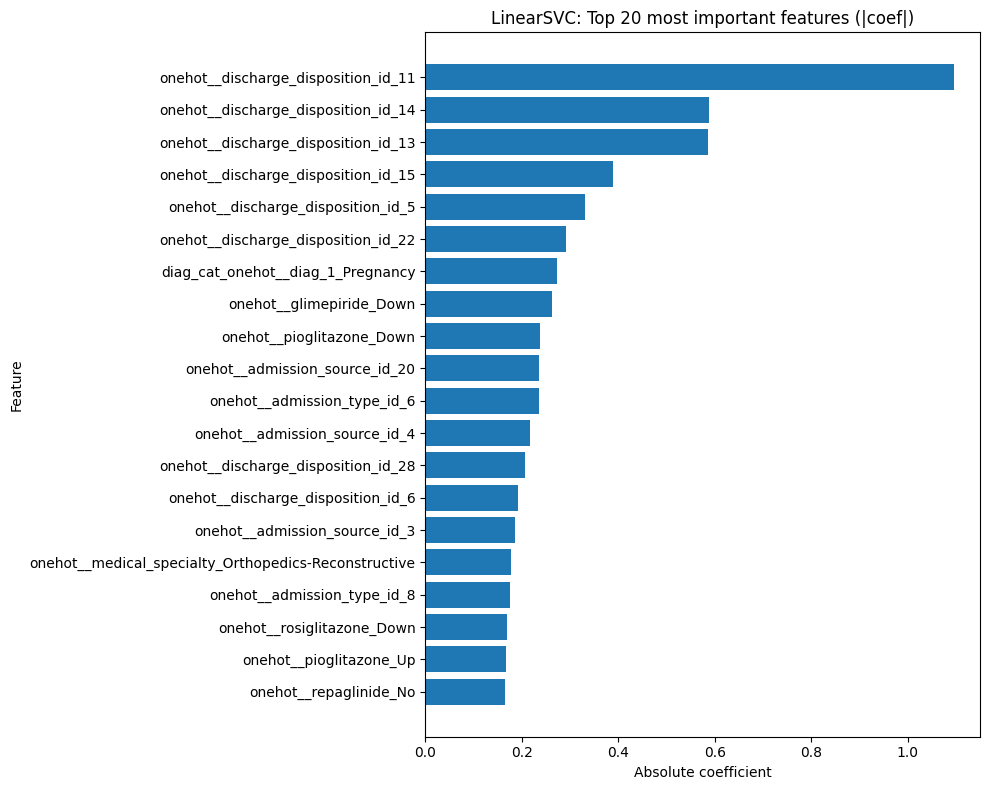

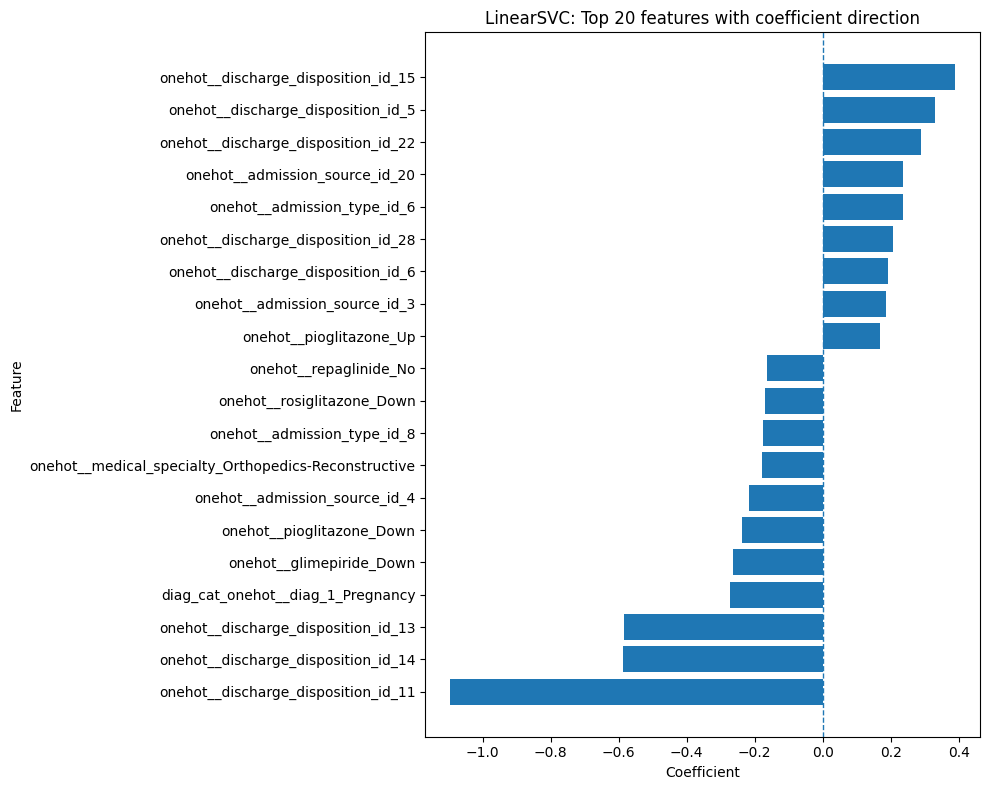

In [70]:
svm_importance_df = extract_linear_feature_importance(model, X_train)

print(svm_importance_df.head(20))

plot_top_abs_coefficients(svm_importance_df, model_name="LinearSVC", topk=20)
plot_top_signed_coefficients(svm_importance_df, model_name="LinearSVC", topk=20)

#### RF


In [74]:


def plot_rf_feature_importance(rf_pipe, X_reference,top_n=20, figsize=(10, 8)):
    """
    rf_pipe: 已经 fit 好的 Pipeline，结构为:
             [("preprocess", preprocess_pipe), ("clf", RandomForestClassifier)]
    """
    # 取出预处理器和分类器
    preprocess = rf_pipe.named_steps["preprocess"]
    clf = rf_pipe.named_steps["clf"]

    # 取出预处理后的特征名
    preprocess = rf_pipe.named_steps["preprocess"]
    clf = rf_pipe.named_steps["clf"]

    # 通过 preprocess 变换一次，拿到最终列名
    X_trans = preprocess.transform(X_reference)

    if not isinstance(X_trans, pd.DataFrame):
        raise TypeError(
            "preprocess output is not a pandas DataFrame. "
            "Please check preprocess_pipe.set_output(transform='pandas')."
        )

    feature_names = X_trans.columns

    # 取出随机森林的重要性
    importances = clf.feature_importances_

    # 整理成 DataFrame
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    # 画 top_n
    top_df = imp_df.head(top_n).iloc[::-1]  # 倒序方便 barh 从上到下显示最大值

    plt.figure(figsize=figsize)
    plt.barh(top_df["feature"], top_df["importance"])
    plt.xlabel("Feature importance")
    plt.title(f"Random Forest Feature Importance (Top {top_n})")
    plt.tight_layout()
    plt.show()

    return imp_df

In [72]:
model = joblib.load("saved_models/best_RF.joblib")

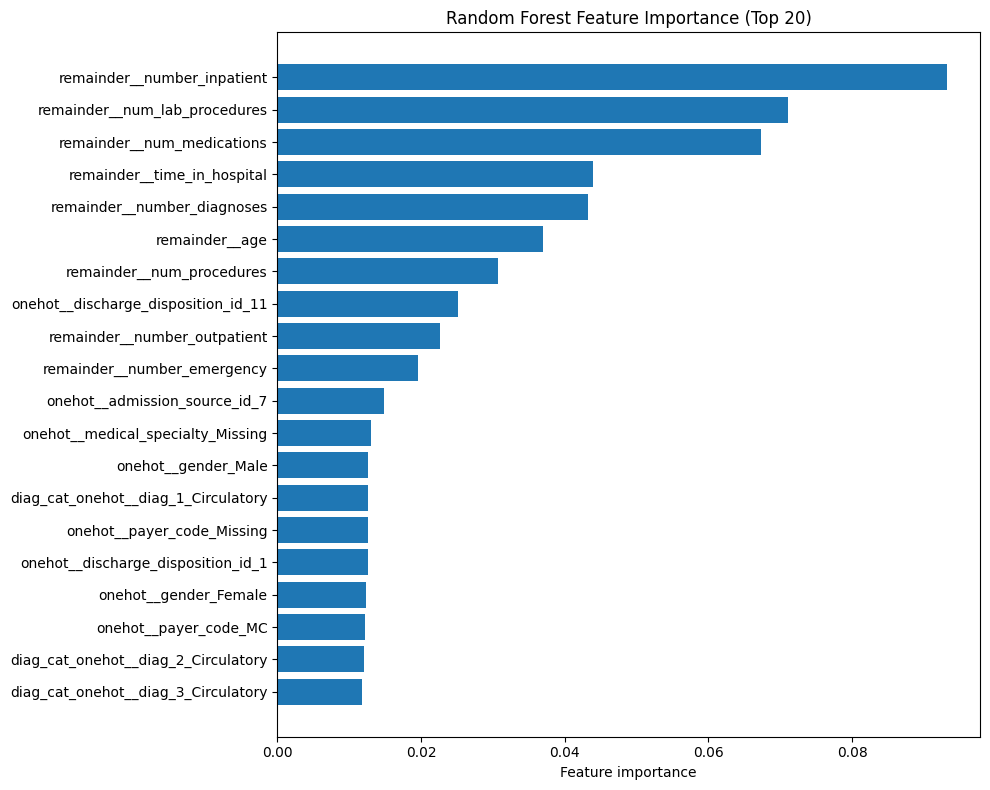

,feature,importance
185,remainder__number_inpatient,0.093126
180,remainder__num_lab_procedures,0.071009
182,remainder__num_medications,0.067249
179,remainder__time_in_hospital,0.043941
186,remainder__number_diagnoses,0.043252
178,remainder__age,0.037029
181,remainder__num_procedures,0.030743
93,onehot__discharge_disposition_id_11,0.025110
183,remainder__number_outpatient,0.022596
184,remainder__number_emergency,0.019576


In [75]:
rf_importance_df = plot_rf_feature_importance(model, X_reference=X_train, top_n=20)
rf_importance_df.head(30)

#### HGB

In [78]:



def plot_hgb_permutation_importance(
    hgb_pipe,
    X_reference,
    y_reference,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    top_n=20,
    figsize=(10, 8)
):
    """
    对 HistGradientBoostingClassifier 计算 permutation importance，
    基于 preprocess 后的最终 DataFrame 特征空间。

    Parameters
    ----------
    hgb_pipe : fitted sklearn Pipeline
        结构应为 [("preprocess", preprocess_pipe), ("clf", HistGradientBoostingClassifier)]
    X_reference : pd.DataFrame
        用于解释的重要性参考集，通常建议用 X_test
    y_reference : pd.Series or np.ndarray
        对应标签
    scoring : str
        如 "roc_auc", "accuracy", "f1"
    n_repeats : int
        permutation 次数
    random_state : int
    top_n : int
        画前多少个特征
    figsize : tuple
    """

    # 取出预处理器和分类器
    preprocess = hgb_pipe.named_steps["preprocess"]
    clf = hgb_pipe.named_steps["clf"]

    # 通过 preprocess 变换一次，拿到最终列名
    X_trans = preprocess.transform(X_reference)

    if not isinstance(X_trans, pd.DataFrame):
        raise TypeError(
            "preprocess output is not a pandas DataFrame. "
            "Please check preprocess_pipe.set_output(transform='pandas')."
        )

    feature_names = X_trans.columns

    # 在 preprocess 后的特征空间上，对 clf 做 permutation importance
    result = permutation_importance(
        estimator=clf,
        X=X_trans,
        y=y_reference,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    # 整理结果
    perm_df = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)

    # 取 top_n 作图
    top_df = perm_df.head(top_n).iloc[::-1]

    plt.figure(figsize=figsize)
    plt.barh(
        top_df["feature"],
        top_df["importance_mean"],
        xerr=top_df["importance_std"]
    )
    plt.xlabel(f"Permutation Importance ({scoring})")
    plt.title(f"HGB Permutation Importance (Top {top_n})")
    plt.tight_layout()
    plt.show()

    return perm_df

In [79]:
model = joblib.load("saved_models/best_HGB.joblib")

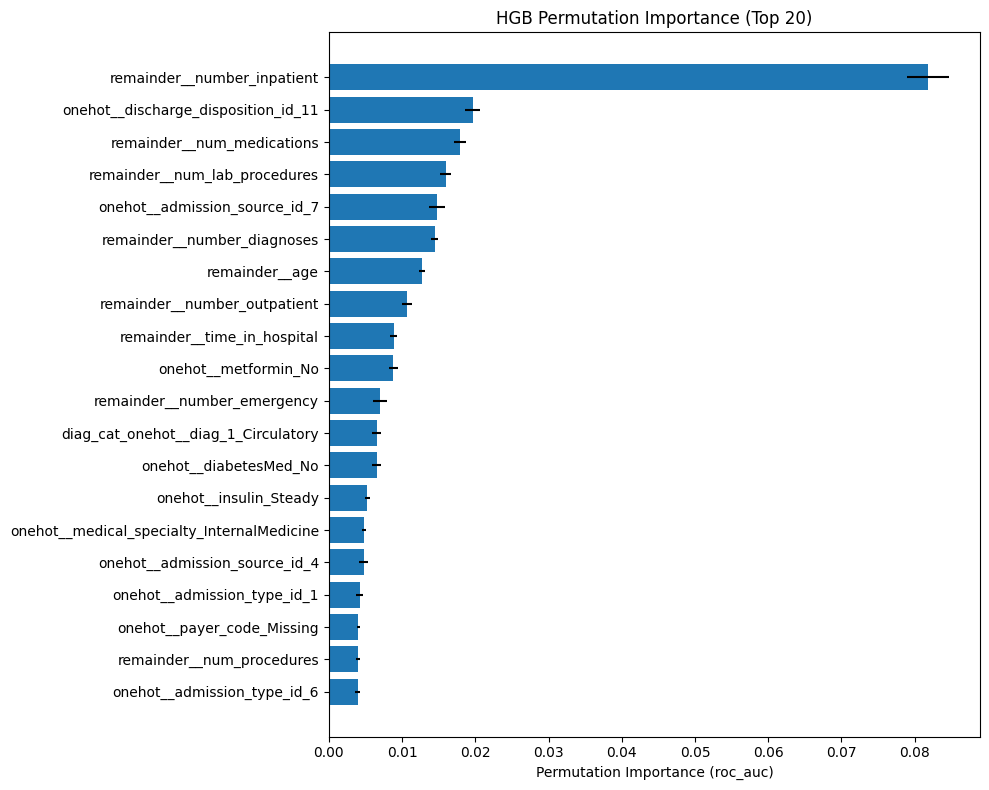

,feature,importance_mean,importance_std
185,remainder__number_inpatient,0.081845,0.002848
93,onehot__discharge_disposition_id_11,0.019649,0.001026
182,remainder__num_medications,0.017922,0.000768
180,remainder__num_lab_procedures,0.015958,0.000772
112,onehot__admission_source_id_7,0.014775,0.001141
186,remainder__number_diagnoses,0.014474,0.000498
178,remainder__age,0.012712,0.000373
183,remainder__number_outpatient,0.010681,0.000650
179,remainder__time_in_hospital,0.008846,0.000428
68,onehot__metformin_No,0.008824,0.000576


In [80]:
hgb_perm_df = plot_hgb_permutation_importance(
    hgb_pipe=model,      # 或 best_hgb_pipe
    X_reference=X_test,
    y_reference=y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    top_n=20
)

hgb_perm_df.head(30)

## ReTrain using Feature selection

#### tool function

In [ ]:
best_rf= joblib.load("saved_models/best_RF.joblib")

In [ ]:
best_rf_params = best_rf.named_steps["clf"].get_params()
print("Best RF hyperparameters:")
for param, value in best_rf_params.items():
    print(f"{param}: {value}")

Best RF hyperparameters:
bootstrap: True
ccp_alpha: 0.0
class_weight: None
criterion: gini
max_depth: None
max_features: sqrt
max_leaf_nodes: None
max_samples: None
min_impurity_decrease: 0.0
min_samples_leaf: 5
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 600
n_jobs: -1
oob_score: False
random_state: 42
verbose: 0
warm_start: False


In [310]:
old_rf_params = {
    "n_estimators": best_rf.named_steps["clf"].n_estimators,
    "max_depth": best_rf.named_steps["clf"].max_depth,
    "min_samples_leaf": best_rf.named_steps["clf"].min_samples_leaf,
    "max_features": best_rf.named_steps["clf"].max_features
}

In [311]:
def build_rf_fs_pipeline(preprocess_pipe, random_state=42):
    """
    preprocess -> feature selection -> final classifier
    """
    selector_estimator = RandomForestClassifier(
        n_estimators=200,
        random_state=random_state,
        n_jobs=-1,
        class_weight=None
    )

    final_clf = RandomForestClassifier(
        **old_rf_params,
        random_state=random_state,
        n_jobs=-1,
        class_weight=None
    )

    pipe = Pipeline(steps=[
        ("preprocess", clone(preprocess_pipe)),
        ("feature_selection", SelectFromModel(
            estimator=selector_estimator,
            threshold="median",     # 会在 param_grid 里继续调
            prefit=False
        )),
        ("clf", final_clf)
    ])

    return pipe

In [312]:
rf_fs_param_grid = {

    # feature selection
    "feature_selection__max_features": [None, 50],
    "feature_selection__estimator__max_depth": [8, None],
    "feature_selection__threshold": ["mean", "median"],

}

In [313]:
scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "accuracy": "accuracy",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

In [314]:
def fit_one_rf_fs_run(
    X_train, y_train, groups_train,
    X_test, y_test,
    preprocess_pipe,
    param_grid,
    scoring,
    refit_metric="roc_auc",
    inner_splits=5,
    random_state=42
):
    pipe = build_rf_fs_pipeline(preprocess_pipe, random_state=random_state)

    inner_cv = StratifiedGroupKFold(
        n_splits=inner_splits,
        shuffle=True,
        random_state=random_state
    )

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        refit=refit_metric,
        cv=inner_cv.split(X_train, y_train, groups=groups_train),
        n_jobs=-1,
        verbose=0,
        return_train_score=False
    )

    gs.fit(X_train, y_train)

    best_pipe = gs.best_estimator_

    # ---- test prediction ----
    y_test_pred = best_pipe.predict(X_test)

    # 二分类概率 / score
    if hasattr(best_pipe, "predict_proba"):
        y_test_score = best_pipe.predict_proba(X_test)[:, 1]
    else:
        y_test_score = best_pipe.decision_function(X_test)

    test_scores = {
        "roc_auc": roc_auc_score(y_test, y_test_score),
        "average_precision": average_precision_score(y_test, y_test_score),
        "accuracy": accuracy_score(y_test, y_test_pred),
        "f1": f1_score(y_test, y_test_pred),
        "precision": precision_score(y_test, y_test_pred, zero_division=0),
        "recall": recall_score(y_test, y_test_pred, zero_division=0)
    }

    # best CV score for each metric
    best_idx = gs.best_index_
    cv_scores = {
        metric: gs.cv_results_[f"mean_test_{metric}"][best_idx]
        for metric in scoring.keys()
    }

    return {
        "grid_search": gs,
        "best_pipe": best_pipe,
        "best_params": gs.best_params_,
        "cv_scores": cv_scores,
        "test_scores": test_scores
    }

In [315]:
def extract_selected_features(best_pipe, X_reference):
    """
    从 fitted pipeline 中提取：
    - preprocess 后的全部特征名
    - SelectFromModel 选择掩码
    - 被保留的特征
    """
    preprocess = best_pipe.named_steps["preprocess"]
    selector = best_pipe.named_steps["feature_selection"]


    # 通过 preprocess 变换一次，拿到最终列名
    X_trans = preprocess.transform(X_reference)

    feature_names = preprocess.transform(X_reference).columns
    
    support_mask = selector.get_support()

    selected_features = np.array(feature_names)[support_mask]

    df = pd.DataFrame({
        "feature": feature_names,
        "selected": support_mask
    })

    df_selected = df[df["selected"]].copy().reset_index(drop=True)
    return df_selected

In [316]:
def summarize_selection_frequency(all_selected_features_df, top_n=20):
    freq_df = (
        all_selected_features_df.groupby("feature")
        .size()
        .reset_index(name="selected_count")
        .sort_values("selected_count", ascending=False)
    )

    plt.figure(figsize=(10, 8))
    top_df = freq_df.head(top_n).iloc[::-1]
    plt.barh(top_df["feature"], top_df["selected_count"])
    plt.xlabel("Selection frequency across repeats")
    plt.title(f"Top {top_n} most frequently selected features")
    plt.tight_layout()
    plt.show()

    return freq_df

In [317]:
def run_task5_rf_feature_selection(
    X_train, y_train, groups_train,
    X_test, y_test,
    preprocess_pipe,
    param_grid,
    scoring,
    refit_metric="roc_auc",
    inner_splits=5,
    n_repeats=5,
    base_random_state=42,
    save_dir="saved_models_task5"
):
    os.makedirs(save_dir, exist_ok=True)

    rows = []
    best_overall_cv = -np.inf
    best_overall_pipe = None
    best_overall_params = None
    best_run_id = None

    all_selected_features = []

    for r in range(n_repeats):
        rs = base_random_state + r
        print(f"Repeat {r+1}/{n_repeats}")

        result = fit_one_rf_fs_run(
            X_train=X_train,
            y_train=y_train,
            groups_train=groups_train,
            X_test=X_test,
            y_test=y_test,
            preprocess_pipe=preprocess_pipe,
            param_grid=param_grid,
            scoring=scoring,
            refit_metric=refit_metric,
            inner_splits=inner_splits,
            random_state=rs
        )

        row = {"repeat": r}
        row.update({f"cv_{k}": v for k, v in result["cv_scores"].items()})
        row.update({f"test_{k}": v for k, v in result["test_scores"].items()})
        row["best_params"] = result["best_params"]
        rows.append(row)

        # 提取本次被选中的特征
        selected_df = extract_selected_features(result["best_pipe"], X_reference=X_train)
        selected_df["repeat"] = r
        all_selected_features.append(selected_df)

        # 记录 overall best
        current_cv = result["cv_scores"][refit_metric]
        if current_cv > best_overall_cv:
            best_overall_cv = current_cv
            best_overall_pipe = result["best_pipe"]
            best_overall_params = result["best_params"]
            best_run_id = r

    results_df = pd.DataFrame(rows)

    # 汇总表：mean ± std
    summary_rows = []
    for metric in scoring.keys():
        summary_rows.append({
            "metric": metric,
            "cv_mean": results_df[f"cv_{metric}"].mean(),
            "cv_std": results_df[f"cv_{metric}"].std(ddof=1),
            "test_mean": results_df[f"test_{metric}"].mean(),
            "test_std": results_df[f"test_{metric}"].std(ddof=1)
        })

    summary_df = pd.DataFrame(summary_rows)

    # 保存最佳模型
    best_model_path = os.path.join(save_dir, "best_rf_fs_pipeline.joblib")
    joblib.dump(best_overall_pipe, best_model_path)

    # 汇总所有 repeats 中的特征选择结果
    all_selected_features_df = pd.concat(all_selected_features, axis=0, ignore_index=True)

    return {
        "results_df": results_df,
        "summary_df": summary_df,
        "best_pipe": best_overall_pipe,
        "best_params": best_overall_params,
        "best_run_id": best_run_id,
        "best_model_path": best_model_path,
        "all_selected_features_df": all_selected_features_df
    }

#### training

In [318]:
groups_train = X_train["patient_nbr"].copy()
task5_output = run_task5_rf_feature_selection(
    X_train=X_train,
    y_train=y_train,
    groups_train=groups_train,
    X_test=X_test,
    y_test=y_test,
    preprocess_pipe=preprocess_pipe,
    param_grid=rf_fs_param_grid,
    scoring=scoring,
    refit_metric="roc_auc",
    inner_splits=5,
    n_repeats=3,
    base_random_state=42,
    save_dir="saved_models_task5"
)

Repeat 1/3
Repeat 2/3
Repeat 3/3


In [319]:
print(X_test.shape)

(20354, 49)


In [320]:
# print every item in task5_output
for key, value in task5_output.items():
    print(f"{key}:")
    print(value)
    print("\n" + "="*50 + "\n")


results_df:
   repeat  cv_roc_auc  cv_average_precision  cv_accuracy     cv_f1  \
0       0    0.684336              0.637319     0.635436  0.540651   
1       1    0.682701              0.638371     0.634940  0.539310   
2       2    0.683387              0.637961     0.637861  0.541819   

   cv_precision  cv_recall  test_roc_auc  test_average_precision  \
0      0.633926   0.471318      0.701595                0.654573   
1      0.634173   0.469407      0.700694                0.654823   
2      0.638687   0.470497      0.701787                0.655731   

   test_accuracy   test_f1  test_precision  test_recall  \
0       0.645377  0.562598        0.651875     0.494830   
1       0.645573  0.563476        0.651645     0.496322   
2       0.645819  0.564068        0.651761     0.497175   

                                         best_params  
0  {'feature_selection__estimator__max_depth': 8,...  
1  {'feature_selection__estimator__max_depth': 8,...  
2  {'feature_selection__estimato

In [321]:
# save every summary_df item to json
for key, value in task5_output.items():
    if isinstance(value, pd.DataFrame):
        value.to_json(f"rf_fs_summary_{key}.json", orient="records", lines=True)

In [341]:
model = joblib.load("saved_models_task5/best_rf_fs_pipeline.joblib")

In [342]:
selector = model.named_steps["feature_selection"]

selected_features = selector.get_support()

print(selected_features.sum())

94


In [324]:
y_pred = model.predict(X_test)
test_accuracy = roc_auc_score(y_test, y_pred)
print("Test accuracy of loaded model:", test_accuracy)

Test accuracy of loaded model: 0.634455906359606


In [325]:
if hasattr(model.named_steps["clf"], "decision_function"):
    y_score = model.decision_function(X_test)
elif hasattr(model.named_steps["clf"], "predict_proba"):
    y_score = model.predict_proba(X_test)[:, 1]
else:
    y_score = None

test_roc_auc = roc_auc_score(y_test, y_score)
print("Test ROC AUC of loaded model:", test_roc_auc)

Test ROC AUC of loaded model: 0.7015945263909253


In [326]:
test_f1 = f1_score(y_test, y_pred)
print("Test F1 score of loaded model:", test_f1)

Test F1 score of loaded model: 0.5625984729123743


In [327]:
test_recall = recall_score(y_test, y_pred)
print("Test Recall score of loaded model:", test_recall)

Test Recall score of loaded model: 0.49482997548235796
